# M11 Adaptive Vector-Gated Static–Dynamic Message-Passing GNN

This notebook preserves the original data preprocessing and replaces the model
with an upgraded form of the proposed M11 architecture. The two global scalar
weights in M11 are replaced by separate **GMU-style, feature-wise, input-dependent
gates** for self-information and neighbor messages.


## Architecture

The model retains the defining M11 separation between self fusion and neighbor-message
fusion. For source node $j$ at time window $t$:

$$
\mathbf{z}^{N}_{j,t}=\sigma\left(W_g^N
[\mathbf{s}^{N}_{j}\Vert\mathbf{d}^{N}_{j,t}]+b_g^N\right),
$$

$$
\mathbf{m}_{j\rightarrow i,t}=\mathbf{z}^{N}_{j,t}\odot\mathbf{s}^{N}_{j}
+(1-\mathbf{z}^{N}_{j,t})\odot\mathbf{d}^{N}_{j,t}.
$$

For the target node's own information:

$$
\mathbf{z}^{S}_{i,t}=\sigma\left(W_g^S
[\mathbf{s}^{S}_{i}\Vert\mathbf{d}^{S}_{i,t}]+b_g^S\right),
$$

$$
\mathbf{e}^{S}_{i,t}=\mathbf{z}^{S}_{i,t}\odot\mathbf{s}^{S}_{i}
+(1-\mathbf{z}^{S}_{i,t})\odot\mathbf{d}^{S}_{i,t}.
$$

Incoming messages are summed, concatenated with the gated self-representation,
and passed to the update MLP. Gate values near 1 favor static information; values
near 0 favor dynamic information.


## What remains unchanged

- Original data loading and feature extraction
- Exponential smoothing and log transformation
- Train-only normalization
- Sliding-window construction and supplied splits
- Optimizer, loss family, evaluation metrics, and downstream plot types

Only the model and gate-specific analyses differ from the GMU-GNN notebook.


In [77]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *
from torch_geometric.loader import DataLoader


# Configuration


In [78]:
seed = 42
set_seed(seed)

num_epochs = 100

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'M11_Gate_only_Explainability_normalized_100_epoch'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
model_used = "M11_Adaptive_Vector_Gated_GNN"     

output_folder = f"results/inductive_learning/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)


# Load dataset

In [79]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [80]:
df_nodes.shape

(14640, 159)

# Label nodes

In [81]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [82]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [83]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [84]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [85]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [86]:
static_dt.shape

(14640, 11)

# Normalize features


# Smooth dynamic data

In [87]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

# global_min = dynamic_dt_smooth_log.min().min()
# global_max = dynamic_dt_smooth_log.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

dynamic_dt_smooth_log = pd.DataFrame(dynamic_dt_smooth_log)
static_dt = pd.DataFrame(static_dt)

# scaler = MinMaxScaler()

# static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

# Convert to tensors

In [88]:
dynamic_tensor = torch.tensor(dynamic_dt_smooth_log.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [89]:
print(dynamic_tensor.shape)
print(static_tensor.shape)

torch.Size([14640, 144])
torch.Size([14640, 11])


# Sliding Window approach

In [90]:
# # Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

# train_dataset = CrimeWindowPyGDataset(
# # train_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=0,
#     end_t=TRAIN_END
# )

# test_dataset = CrimeWindowPyGDataset(
# # test_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=TRAIN_END,
#     end_t=T
# )

# Inductive Learning

In [91]:
import torch

def filter_and_reindex(data, allowed_nodes):

    # ---- Step 1: mask nodes ----
    mask = torch.isin(data.node_ids, allowed_nodes)

    if mask.sum() == 0:
        return None

    # ---- Step 2: filter node features ----
    new_x_static = data.x_static[mask]
    new_x_dynamic = data.x_dynamic[mask]
    new_y = data.y[mask]

    # IMPORTANT: keep original node ids temporarily
    old_node_ids = data.node_ids[mask]

    # ---- Step 3: create mapping old → new index ----
    # Example: {5:0, 10:1, 20:2}
    unique_nodes = old_node_ids
    mapping = {int(old_id): i for i, old_id in enumerate(unique_nodes)}

    # ---- Step 4: filter edges ----
    src, dst = data.edge_index

    edge_mask = torch.isin(src, old_node_ids) & torch.isin(dst, old_node_ids)

    src = src[edge_mask]
    dst = dst[edge_mask]

    # ---- Step 5: reindex edges ----
    new_src = torch.tensor([mapping[int(s)] for s in src])
    new_dst = torch.tensor([mapping[int(d)] for d in dst])

    new_edge_index = torch.stack([new_src, new_dst], dim=0)

    # ---- Step 6: create new node ids (0...N-1) ----
    new_node_ids = torch.arange(len(unique_nodes))

    # ---- Step 7: update time_id ----
    new_time_id = data.time_id[mask]

    # ---- Step 8: return new Data ----
    new_data = data.clone()

    new_data.x_static = new_x_static
    new_data.x_dynamic = new_x_dynamic
    new_data.y = new_y
    new_data.edge_index = new_edge_index
    new_data.node_ids = new_node_ids   # ✅ reindexed
    new_data.time_id = new_time_id
    new_data.num_nodes = len(new_node_ids)

    return new_data

from torch.utils.data import Dataset

class InductiveWrapperDataset(Dataset):
    def __init__(self, base_dataset, allowed_nodes):
        self.base_dataset = base_dataset
        self.allowed_nodes = allowed_nodes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        data = self.base_dataset[idx]

        new_data = filter_and_reindex(data, self.allowed_nodes)

        # Handle rare empty case
        if new_data is None:
            return self.__getitem__((idx + 1) % len(self))

        return new_data
    
    import numpy as np

def split_nodes(num_nodes, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    nodes = np.arange(num_nodes)
    np.random.shuffle(nodes)

    split = int(train_ratio * num_nodes)

    train_nodes = torch.tensor(nodes[:split])
    test_nodes = torch.tensor(nodes[split:])

    return train_nodes, test_nodes

## Split nodes

In [92]:
train_nodes, test_nodes = split_nodes(static_tensor.shape[0])

## Compute normalization ONLY from TRAIN

Dynamic normalization

In [93]:
train_dynamic = dynamic_tensor[train_nodes][:, :TRAIN_END]

min_val = train_dynamic.min()
max_val = train_dynamic.max()

dynamic_tensor_norm = (dynamic_tensor - min_val) / (max_val - min_val + 1e-8)

In [94]:
dynamic_tensor.max()

tensor(3.8104)

Static normalization

In [95]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_static = static_tensor[train_nodes]

scaler.fit(train_static)

static_tensor_norm = torch.tensor(
    scaler.transform(static_tensor),
    dtype=torch.float32
)

Temporal Split

In [96]:
train_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)

# Inductive Split on nodes

In [97]:

# train_dataset = InductiveWrapperDataset(train_dataset, train_nodes)
# test_dataset = InductiveWrapperDataset(test_dataset, test_nodes)

In [98]:
sample = train_dataset[0]

print(sample.x_static.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 11])
tensor(14639) 14640


In [99]:
sample = test_dataset[0]

print(sample.x_dynamic.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 5])
tensor(14639) 14640


# Adaptive vector-gated M11 message-passing layer

Unlike GMU-GNN, fusion is performed separately inside `message()` and `update()`.
The neighbor gate is source-node/time dependent and shared across that source
node's outgoing edges. It is not receiver-specific edge attention.


In [100]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch_geometric.nn import MessagePassing


# class AdaptiveVectorGatedStaticDynamicGNN(MessagePassing):
#     """M11 upgraded with separate GMU-style feature-wise gates."""

#     def __init__(self, in_static, window_size, hidden_dim=64, out_dim=1, dropout=0.2):
#         super().__init__(aggr="add")
#         self.hidden_dim = hidden_dim

#         # Separate projections preserve M11's self/neighbor distinction.
#         self.lin_stat_self = nn.Linear(in_static, hidden_dim)
#         self.lin_dyn_self = nn.Linear(window_size, hidden_dim)
#         self.lin_stat_neigh = nn.Linear(in_static, hidden_dim)
#         self.lin_dyn_neigh = nn.Linear(window_size, hidden_dim)

#         # GMU-style vector gates: [*, 2H] -> [*, H].
#         self.gate_self = nn.Linear(2 * hidden_dim, hidden_dim)
#         self.gate_neigh = nn.Linear(2 * hidden_dim, hidden_dim)

#         # Original M11 update MLP (unchanged).
#         hidden_dim_2 = 64
#         self.update_mlp = nn.Sequential(
#             nn.Linear(2 * hidden_dim, hidden_dim_2),
#             nn.ReLU(),
#         )
#         # Original M11 classifier (unchanged).
#         self.classif_mlp = nn.Sequential(
#             nn.Linear(hidden_dim_2, 128),
#             nn.ReLU(),
#             nn.Linear(128, out_dim),
#         )

#         self.last_gate_self = None
#         self.last_gate_neigh_edges = None
#         self.reset_parameters()

#     def reset_parameters(self):
#         for module in self.modules():
#             if isinstance(module, nn.Linear):
#                 nn.init.xavier_uniform_(module.weight)
#                 nn.init.zeros_(module.bias)

#     def _neighbor_components(self, x_static, x_dynamic):
#         # Original M11 linear projections (unchanged; no tanh).
#         stat = self.lin_stat_neigh(x_static)
#         dyn = self.lin_dyn_neigh(x_dynamic)
#         gate = torch.sigmoid(self.gate_neigh(torch.cat([stat, dyn], dim=-1)))
#         return stat, dyn, gate

#     def _self_components(self, x_static, x_dynamic):
#         # Original M11 linear projections (unchanged; no tanh).
#         stat = self.lin_stat_self(x_static)
#         dyn = self.lin_dyn_self(x_dynamic)
#         gate = torch.sigmoid(self.gate_self(torch.cat([stat, dyn], dim=-1)))
#         return stat, dyn, gate

#     def message(self, x_static_j, x_dynamic_j):
#         stat, dyn, gate = self._neighbor_components(x_static_j, x_dynamic_j)
#         self.last_gate_neigh_edges = gate.detach()
#         return gate * stat + (1.0 - gate) * dyn

#     def update(self, aggr_out, x_static, x_dynamic):
#         stat, dyn, gate = self._self_components(x_static, x_dynamic)
#         self.last_gate_self = gate.detach()
#         self_emb = gate * stat + (1.0 - gate) * dyn
#         return self.update_mlp(torch.cat([self_emb, aggr_out], dim=-1))

#     def forward(self, x_static, x_dynamic, edge_index, return_details=False):
#         # Node-level neighbor gates equal the gates used by outgoing messages,
#         # before PyG expands source nodes onto edges. This avoids degree-weighted analysis.
#         _, _, neighbor_gate_nodes = self._neighbor_components(x_static, x_dynamic)
#         _, _, self_gate_nodes = self._self_components(x_static, x_dynamic)

#         hidden = self.propagate(
#             edge_index,
#             x_static=x_static,
#             x_dynamic=x_dynamic,
#         )
#         prediction = self.classif_mlp(hidden).squeeze(-1)

#         if return_details:
#             return prediction, hidden, {
#                 "self_gate": self_gate_nodes,
#                 "neighbor_gate": neighbor_gate_nodes,
#             }
#         return prediction, hidden


# class CrimeForecastModel(nn.Module):
#     def __init__(self, in_static, window_size, hidden_dim=64):
#         super().__init__()
#         self.gnn = AdaptiveVectorGatedStaticDynamicGNN(
#             in_static=in_static,
#             window_size=window_size,
#             hidden_dim=hidden_dim,
#             out_dim=1,
#         )

#     def forward(self, x_static, x_dynamic, edge_index, return_details=False):
#         return self.gnn(x_static, x_dynamic, edge_index, return_details=return_details)


In [101]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing


class AdaptiveVectorGatedStaticDynamicGNN(MessagePassing):
    """M11 with feature-wise gates and separately normalized modality branches."""

    def __init__(
        self,
        in_static,
        window_size,
        hidden_dim=64,
        out_dim=1,
        dropout=0.2
    ):
        super().__init__(aggr="add")
        self.hidden_dim = hidden_dim

        # Separate projections preserve M11's self/neighbor distinction.
        self.lin_stat_self = nn.Linear(in_static, hidden_dim)
        self.lin_dyn_self = nn.Linear(window_size, hidden_dim)

        self.lin_stat_neigh = nn.Linear(in_static, hidden_dim)
        self.lin_dyn_neigh = nn.Linear(window_size, hidden_dim)

        # Separate normalization for each projected modality branch.
        self.norm_stat_self = nn.LayerNorm(hidden_dim)
        self.norm_dyn_self = nn.LayerNorm(hidden_dim)

        self.norm_stat_neigh = nn.LayerNorm(hidden_dim)
        self.norm_dyn_neigh = nn.LayerNorm(hidden_dim)

        # Feature-wise vector gates: [*, 2H] -> [*, H].
        self.gate_self = nn.Linear(
            2 * hidden_dim,
            hidden_dim
        )
        self.gate_neigh = nn.Linear(
            2 * hidden_dim,
            hidden_dim
        )

        # Original M11 update MLP.
        hidden_dim_2 = 64
        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim_2),
            nn.ReLU(),
        )

        # Original M11 classifier.
        self.classif_mlp = nn.Sequential(
            nn.Linear(hidden_dim_2, 128),
            nn.ReLU(),
            nn.Linear(128, out_dim),
        )

        self.last_gate_self = None
        self.last_gate_neigh_edges = None

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def _neighbor_components(self, x_static, x_dynamic):
        # Project each modality independently.
        stat = self.lin_stat_neigh(x_static)
        dyn = self.lin_dyn_neigh(x_dynamic)

        # Normalize each modality independently before gate calculation
        # and before gated fusion.
        stat = self.norm_stat_neigh(stat)
        dyn = self.norm_dyn_neigh(dyn)

        gate_input = torch.cat(
            [stat, dyn],
            dim=-1
        )

        gate = torch.sigmoid(
            self.gate_neigh(gate_input)
        )

        return stat, dyn, gate

    def _self_components(self, x_static, x_dynamic):
        # Project each modality independently.
        stat = self.lin_stat_self(x_static)
        dyn = self.lin_dyn_self(x_dynamic)

        # Normalize each modality independently before gate calculation
        # and before gated fusion.
        stat = self.norm_stat_self(stat)
        dyn = self.norm_dyn_self(dyn)

        gate_input = torch.cat(
            [stat, dyn],
            dim=-1
        )

        gate = torch.sigmoid(
            self.gate_self(gate_input)
        )

        return stat, dyn, gate

    def message(self, x_static_j, x_dynamic_j):
        stat, dyn, gate = self._neighbor_components(
            x_static_j,
            x_dynamic_j
        )

        self.last_gate_neigh_edges = gate.detach()

        return (
            gate * stat
            + (1.0 - gate) * dyn
        )

    def update(self, aggr_out, x_static, x_dynamic):
        stat, dyn, gate = self._self_components(
            x_static,
            x_dynamic
        )

        self.last_gate_self = gate.detach()

        self_emb = (
            gate * stat
            + (1.0 - gate) * dyn
        )

        fused = torch.cat(
            [self_emb, aggr_out],
            dim=-1
        )

        return self.update_mlp(fused)

    def forward(
        self,
        x_static,
        x_dynamic,
        edge_index,
        return_details=False
    ):
        # Node-level gates for explainability analysis.
        _, _, neighbor_gate_nodes = self._neighbor_components(
            x_static,
            x_dynamic
        )

        _, _, self_gate_nodes = self._self_components(
            x_static,
            x_dynamic
        )

        hidden = self.propagate(
            edge_index,
            x_static=x_static,
            x_dynamic=x_dynamic,
        )

        prediction = self.classif_mlp(
            hidden
        ).squeeze(-1)

        if return_details:
            return prediction, hidden, {
                "self_gate": self_gate_nodes,
                "neighbor_gate": neighbor_gate_nodes,
            }

        return prediction, hidden


class CrimeForecastModel(nn.Module):
    def __init__(
        self,
        in_static,
        window_size,
        hidden_dim=64
    ):
        super().__init__()

        self.gnn = AdaptiveVectorGatedStaticDynamicGNN(
            in_static=in_static,
            window_size=window_size,
            hidden_dim=hidden_dim,
            out_dim=1,
        )

    def forward(
        self,
        x_static,
        x_dynamic,
        edge_index,
        return_details=False
    ):
        return self.gnn(
            x_static,
            x_dynamic,
            edge_index,
            return_details=return_details
        )

# Model initialization


In [102]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
S = static_tensor.size(1)

model = CrimeForecastModel(
    in_static=S,
    window_size=W,
    hidden_dim=64,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(model)
print("Device:", device)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


CrimeForecastModel(
  (gnn): AdaptiveVectorGatedStaticDynamicGNN()
)
Device: cpu
Trainable parameters: 36033


# Training

The model is trained for the configured fixed number of epochs because the
supplied preprocessing defines training and test datasets but no validation
dataset. The test set is not used for early stopping or model selection.


In [103]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_nodes = 0
    self_gate_sum = 0.0
    neighbor_gate_sum = 0.0
    self_gate_elements = 0
    neighbor_gate_elements = 0

    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        prediction, _, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)
        loss = criterion(prediction, target)
        loss.backward()
        optimizer.step()

        n = target.numel()
        total_loss += loss.item() * n
        total_nodes += n
        self_gate_sum += details["self_gate"].detach().sum().item()
        neighbor_gate_sum += details["neighbor_gate"].detach().sum().item()
        self_gate_elements += details["self_gate"].numel()
        neighbor_gate_elements += details["neighbor_gate"].numel()

    return (
        total_loss / max(total_nodes, 1),
        self_gate_sum / max(self_gate_elements, 1),
        neighbor_gate_sum / max(neighbor_gate_elements, 1),
    )


train_loss_history = []
self_static_gate_history = []
neighbor_static_gate_history = []

for epoch in range(num_epochs):
    train_loss, self_gate_mean, neighbor_gate_mean = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    train_loss_history.append(train_loss)
    self_static_gate_history.append(self_gate_mean)
    neighbor_static_gate_history.append(neighbor_gate_mean)

    if epoch == 0 or (epoch + 1) % 10 == 0 or epoch + 1 == num_epochs:
        print(
            f"Epoch {epoch + 1:03d}/{num_epochs} | Train MSE: {train_loss:.6f} | "
            f"Self static: {self_gate_mean:.4f} | "
            f"Neighbor static: {neighbor_gate_mean:.4f}"
        )


Epoch 001/100 | Train MSE: 0.016871 | Self static: 0.4857 | Neighbor static: 0.5123
Epoch 010/100 | Train MSE: 0.001163 | Self static: 0.4715 | Neighbor static: 0.4998
Epoch 020/100 | Train MSE: 0.000601 | Self static: 0.4763 | Neighbor static: 0.4936
Epoch 030/100 | Train MSE: 0.000295 | Self static: 0.4804 | Neighbor static: 0.4884
Epoch 040/100 | Train MSE: 0.000161 | Self static: 0.4837 | Neighbor static: 0.4852
Epoch 050/100 | Train MSE: 0.000118 | Self static: 0.4857 | Neighbor static: 0.4836
Epoch 060/100 | Train MSE: 0.000096 | Self static: 0.4869 | Neighbor static: 0.4830
Epoch 070/100 | Train MSE: 0.000097 | Self static: 0.4880 | Neighbor static: 0.4825
Epoch 080/100 | Train MSE: 0.000094 | Self static: 0.4889 | Neighbor static: 0.4814
Epoch 090/100 | Train MSE: 0.000076 | Self static: 0.4899 | Neighbor static: 0.4812
Epoch 100/100 | Train MSE: 0.000096 | Self static: 0.4910 | Neighbor static: 0.4810


### Easy explanation — training output

**What is the purpose?** Training MSE tells us how well the model is fitting the training
examples. Lower is better. The two gate values show the average fraction assigned to static
information during training; the dynamic fraction is `1 − static gate`.

**What happened?** MSE fell from **0.016871** at epoch 1 to **0.000096** at epoch 100. Most
improvement happened early, but meaningful improvement continued after epoch 50. The self
static gate finished near 0.491 and the neighbor static gate near 0.481, so both averages
slightly favor dynamic information.

Loss was **0.000076 at epoch 90** and **0.000096 at epoch 100**. This small rise is normal
mini-batch optimization noise, but it means the last epoch was not the lowest-training-loss
epoch. Because there is no validation checkpoint, we cannot claim epoch 100 is the optimal
stopping point.

**Conclusion.** Longer training was useful. It solved the under-convergence seen at 50 epochs,
but future experiments should use a predeclared training-only or chronological-validation
checkpoint rule rather than automatically taking the final epoch.


# Training and gate-history plots


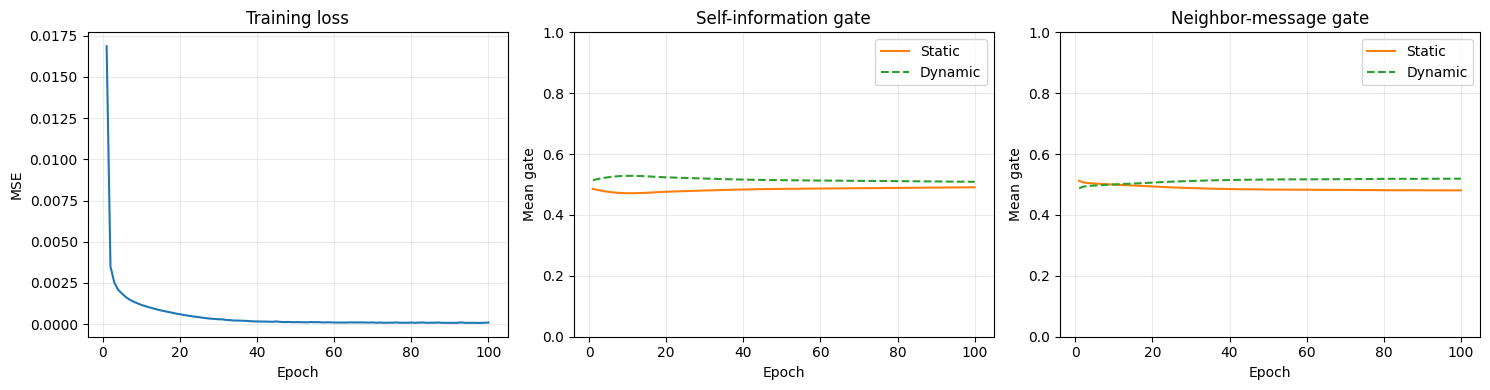

In [104]:
epochs = np.arange(1, len(train_loss_history) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, train_loss_history, color="tab:blue")
axes[0].set(title="Training loss", xlabel="Epoch", ylabel="MSE")

axes[1].plot(epochs, self_static_gate_history, label="Static", color="tab:orange")
axes[1].plot(epochs, 1.0-np.asarray(self_static_gate_history), label="Dynamic",
             color="tab:green", linestyle="--")
axes[1].set(title="Self-information gate", xlabel="Epoch", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()

axes[2].plot(epochs, neighbor_static_gate_history, label="Static", color="tab:orange")
axes[2].plot(epochs, 1.0-np.asarray(neighbor_static_gate_history), label="Dynamic",
             color="tab:green", linestyle="--")
axes[2].set(title="Neighbor-message gate", xlabel="Epoch", ylabel="Mean gate", ylim=(0, 1))
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_vector_gate_training_history.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — training curves

**Left plot: training loss.** A steep downward curve means the model learned quickly. The
later flatter part means improvements became smaller. The curve does not diverge, so training
is stable.

**Middle and right plots: gate histories.** These plots show how the *average* self and
neighbor modality weights changed while learning. They stay close to 0.5, but this does not
mean individual gates are all 0.5. Later analyses show that the 64 gate dimensions are very
different and their averages cancel.

**Compared with 50 epochs.** At epoch 50, training MSE was 0.000118; continued training reached
lower values. Therefore the earlier normalized model had not fully converged.


# Test evaluation and collection


In [105]:
@torch.no_grad()
def evaluate_and_collect_m11(model, loader, device, ablation=None):
    model.eval()
    predictions_per_time, targets_per_time = [], []
    embeddings_per_time = []
    self_gates_per_time, neighbor_gates_per_time = [], []
    node_ids_per_time, time_ids_per_time = [], []

    for step, data in enumerate(loader):
        data = data.to(device)
        x_static, x_dynamic = data.x_static, data.x_dynamic
        if ablation == "static_only":
            x_dynamic = torch.zeros_like(x_dynamic)
        elif ablation == "dynamic_only":
            x_static = torch.zeros_like(x_static)

        prediction, embedding, details = model(
            x_static, x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)
        n = target.numel()
        node_ids = getattr(data, "node_ids", torch.arange(n, device=device)).reshape(-1)
        time_ids = getattr(data, "time_id", torch.tensor(step, device=device)).reshape(-1)
        if node_ids.numel() == 1 and n > 1:
            node_ids = node_ids.repeat(n)
        if time_ids.numel() == 1 and n > 1:
            time_ids = time_ids.repeat(n)

        predictions_per_time.append(prediction.cpu().numpy())
        targets_per_time.append(target.cpu().numpy())
        embeddings_per_time.append(embedding.cpu())
        self_gates_per_time.append(details["self_gate"].cpu())
        neighbor_gates_per_time.append(details["neighbor_gate"].cpu())
        node_ids_per_time.append(node_ids.cpu())
        time_ids_per_time.append(time_ids.cpu())

    y_pred = np.concatenate(predictions_per_time)
    y_true = np.concatenate(targets_per_time)
    error = y_pred - y_true
    mse = float(np.mean(error ** 2))
    variance = float(np.sum((y_true-y_true.mean()) ** 2))
    metrics = {
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": float(np.mean(np.abs(error))),
        "R2": float(1.0-np.sum(error ** 2)/variance) if variance > 0 else float("nan"),
    }
    details = {
        "predictions_per_time": predictions_per_time,
        "targets_per_time": targets_per_time,
        "embeddings_per_time": embeddings_per_time,
        "self_gates": torch.cat(self_gates_per_time),
        "neighbor_gates": torch.cat(neighbor_gates_per_time),
        "node_ids": torch.cat(node_ids_per_time),
        "time_ids": torch.cat(time_ids_per_time),
    }
    return metrics, details


metrics, test_results = evaluate_and_collect_m11(model, test_loader, device)
preds_per_t = test_results["predictions_per_time"]
targets_per_t = test_results["targets_per_time"]
display(pd.DataFrame([metrics]))
pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"]).to_csv(
    os.path.join(output_folder, "metrics_M11_AdaptiveVectorGate.csv"), index=False
)


,MSE,RMSE,MAE,R2
0,0.000065,0.008044,0.005234,0.977696


### Easy explanation — test prediction metrics

**What do these metrics mean?**

- **MSE** averages squared errors. It penalizes large mistakes strongly. Lower is better.
- **RMSE** is the square root of MSE and is in the same scale as crime intensity. Lower is better.
- **MAE** is the average absolute prediction error. Lower is better and easier to interpret.
- **R²** is the fraction of target variation explained by the model. Values closer to 1 are better.

**Result.** MSE is **0.000065**, RMSE **0.008044**, MAE **0.005234**, and R² **0.977696**.
The model explains about 97.8% of the variation in the normalized target, which is strong.

**Compared with the 50-epoch normalized run.** MSE improved from 0.000110 to 0.000065
(approximately **41% lower**), and R² improved from 0.9619 to 0.9777. Longer training clearly
helped.

**Compared with the earlier model without LayerNorm.** MSE is slightly better
(0.000065 versus 0.000067) and R² is slightly better, but MAE is worse
(0.005234 versus 0.004360). Therefore the models are broadly competitive; one run is not
enough to declare a final winner.


# Global self and neighbor modality contributions

Each gate is feature-wise. We average over hidden dimensions for compact
node-time summaries. Gate means describe learned mixing, not causal importance.


,Role,Static gate,Dynamic gate
0,Self information,0.489469,0.510531
1,Neighbor messages,0.481459,0.518541


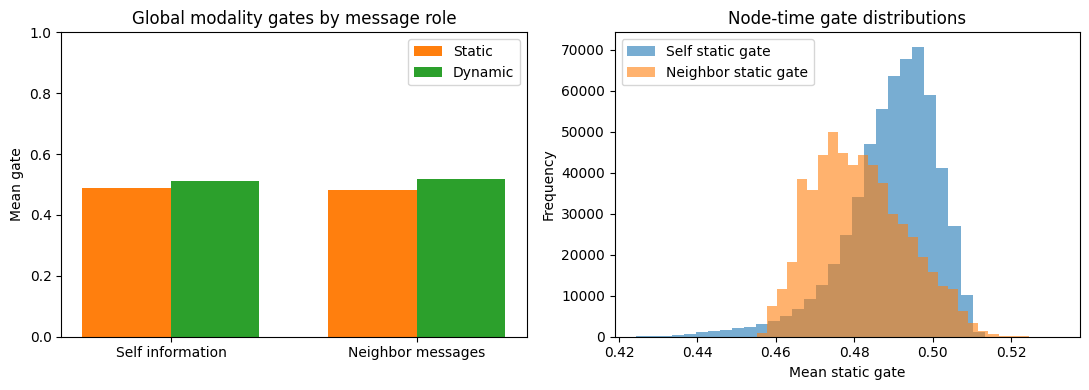

In [106]:
self_case_gate = test_results["self_gates"].mean(dim=1)
neighbor_case_gate = test_results["neighbor_gates"].mean(dim=1)

self_static = self_case_gate.mean().item()
neighbor_static = neighbor_case_gate.mean().item()

summary = pd.DataFrame({
    "Role": ["Self information", "Neighbor messages"],
    "Static gate": [self_static, neighbor_static],
    "Dynamic gate": [1.0-self_static, 1.0-neighbor_static],
})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(2)
width = 0.36
axes[0].bar(x-width/2, summary["Static gate"], width, label="Static", color="tab:orange")
axes[0].bar(x+width/2, summary["Dynamic gate"], width, label="Dynamic", color="tab:green")
axes[0].set_xticks(x, summary["Role"])
axes[0].set(title="Global modality gates by message role", ylabel="Mean gate", ylim=(0, 1))
axes[0].legend()

axes[1].hist(self_case_gate.numpy(), bins=30, alpha=0.60, label="Self static gate")
axes[1].hist(neighbor_case_gate.numpy(), bins=30, alpha=0.60, label="Neighbor static gate")
axes[1].set(title="Node-time gate distributions", xlabel="Mean static gate", ylabel="Frequency")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_global_vector_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — global modality gates

**Question answered.** On average, does each message role favor static socioeconomic data or
dynamic crime history?

The self static gate is **0.4895**, so its dynamic gate is 0.5105. The neighbor static gate is
**0.4815**, so its dynamic gate is 0.5185. Both pathways have only a small average preference
for dynamic information.

The histogram shows distributions of each node-time *mean* gate. The self distribution is
shifted slightly to the right of the neighbor distribution. A value near 0.5 means balanced
mixing only after averaging 64 dimensions; it does not prove that every dimension is balanced.

**Conclusion.** Globally, both roles use both modalities. Neighbor messages are slightly more
dynamic on average, while self information is slightly more static than neighbor information.


# Spatial and temporal self/neighbor gate analysis


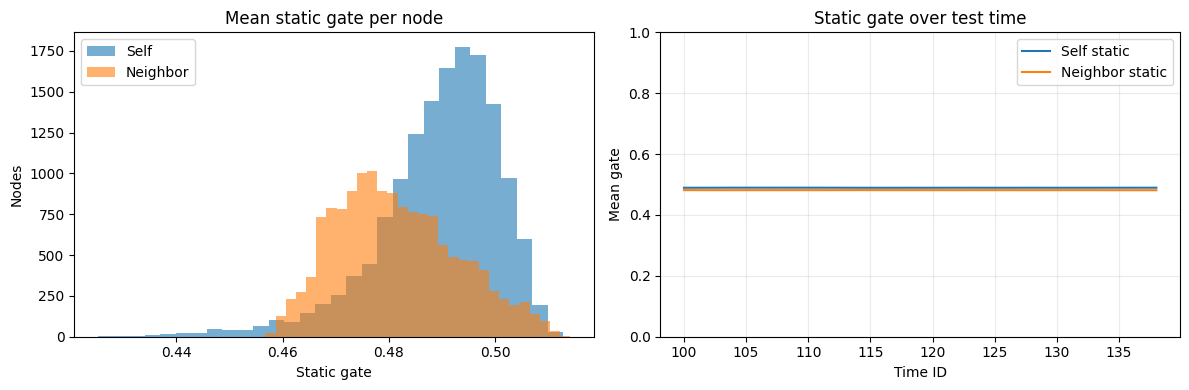

In [107]:
gate_frame = pd.DataFrame({
    "node_id": test_results["node_ids"].numpy(),
    "time_id": test_results["time_ids"].numpy(),
    "self_static_gate": self_case_gate.numpy(),
    "neighbor_static_gate": neighbor_case_gate.numpy(),
})
gate_frame["combined_static_gate"] = gate_frame[["self_static_gate", "neighbor_static_gate"]].mean(axis=1)

node_gate = gate_frame.groupby("node_id", as_index=False)[
    ["self_static_gate", "neighbor_static_gate", "combined_static_gate"]
].mean()
time_gate = gate_frame.groupby("time_id", as_index=False)[
    ["self_static_gate", "neighbor_static_gate"]
].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(node_gate["self_static_gate"], bins=30, alpha=0.6, label="Self")
axes[0].hist(node_gate["neighbor_static_gate"], bins=30, alpha=0.6, label="Neighbor")
axes[0].set(title="Mean static gate per node", xlabel="Static gate", ylabel="Nodes")
axes[0].legend()

axes[1].plot(time_gate["time_id"], time_gate["self_static_gate"], label="Self static")
axes[1].plot(time_gate["time_id"], time_gate["neighbor_static_gate"], label="Neighbor static")
axes[1].set(title="Static gate over test time", xlabel="Time ID", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_spatial_temporal_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()

gate_frame.to_csv(os.path.join(output_folder, "m11_node_time_gate_values.csv"), index=False)


### Easy explanation — spatial and temporal mean gates

**Left plot: variation across nodes.** Each value is one street segment's average gate over
the test period. The distributions overlap, so most streets have similar mean modality
balance. Self gates are generally a little higher than neighbor gates.

**Right plot: variation across time.** The citywide averages are almost flat. This means the
whole city does not switch collectively from static to dynamic information during the test
period.

**What it does not mean.** Flat global averages do not mean the model is non-adaptive.
Different nodes and latent dimensions can change in opposite directions and cancel in the
average. Feature-wise and within-node analyses are needed to see that behavior.


# Representative dynamic-, balanced-, and static-heavy nodes


{'Dynamic-heavy': 9274, 'Balanced': 8701, 'Static-heavy': 5447}


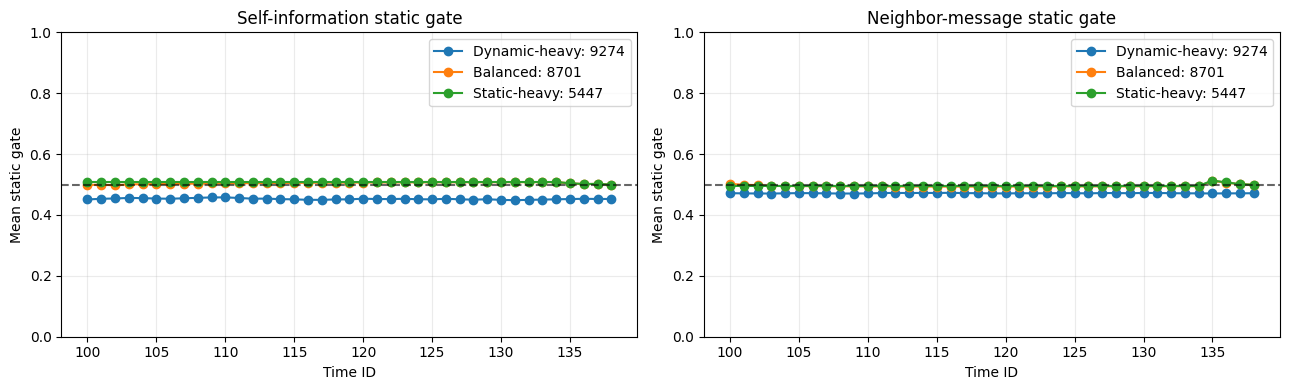

In [108]:
node_gate_sorted = node_gate.sort_values("combined_static_gate").reset_index(drop=True)
dynamic_heavy_node = int(node_gate_sorted.iloc[0]["node_id"])
balanced_idx = (node_gate_sorted["combined_static_gate"]-0.5).abs().idxmin()
balanced_node = int(node_gate_sorted.loc[balanced_idx, "node_id"])
static_heavy_node = int(node_gate_sorted.iloc[-1]["node_id"])
selected_nodes = {
    "Dynamic-heavy": dynamic_heavy_node,
    "Balanced": balanced_node,
    "Static-heavy": static_heavy_node,
}
print(selected_nodes)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, node in selected_nodes.items():
    series = gate_frame[gate_frame["node_id"] == node].sort_values("time_id")
    axes[0].plot(series["time_id"], series["self_static_gate"], marker="o",
                 label=f"{label}: {node}")
    axes[1].plot(series["time_id"], series["neighbor_static_gate"], marker="o",
                 label=f"{label}: {node}")
for ax, title in zip(axes, ["Self-information static gate", "Neighbor-message static gate"]):
    ax.axhline(0.5, color="black", linestyle="--", alpha=0.6)
    ax.set(title=title, xlabel="Time ID", ylabel="Mean static gate", ylim=(0, 1))
    ax.legend()
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_representative_node_gates.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — representative nodes

**Purpose.** This plot gives concrete examples of nodes with the lowest observed mean static
gate, the gate closest to 0.5, and the highest observed mean static gate.

The selected nodes are 9274 (most dynamic), 8701 (closest to balanced), and 5447 (most
static among observed nodes). Their curves remain relatively close to 0.5 and change slowly.

**Important naming caution.** “Static-heavy” means the most static node available in this
test set; it does not necessarily mean its gate is above 0.5 at all times. These are descriptive
examples, not statistically defined dominance classes.


# Modality ablation

This input-ablation test evaluates the trained full model after zeroing one
modality. For a stronger comparison, separately train static-only and
dynamic-only GNN baselines as well.


,Input,MSE,RMSE,MAE,R2
0,Full model,0.000065,0.008044,0.005234,0.977696
1,Static only,0.003718,0.060976,0.028885,-0.281556
2,Dynamic only,0.000130,0.011421,0.006190,0.955037


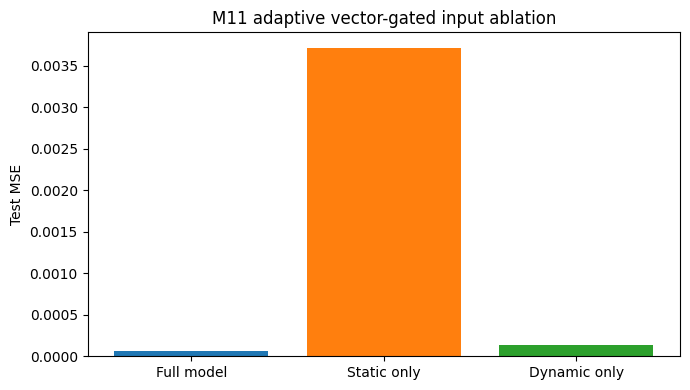

In [109]:
static_metrics, _ = evaluate_and_collect_m11(model, test_loader, device, ablation="static_only")
dynamic_metrics, _ = evaluate_and_collect_m11(model, test_loader, device, ablation="dynamic_only")
ablation_results = pd.DataFrame([
    {"Input": "Full model", **metrics},
    {"Input": "Static only", **static_metrics},
    {"Input": "Dynamic only", **dynamic_metrics},
])
display(ablation_results)
ablation_results.to_csv(os.path.join(output_folder, "m11_ablation_results.csv"), index=False)

plt.figure(figsize=(7, 4))
plt.bar(ablation_results["Input"], ablation_results["MSE"],
        color=["tab:blue", "tab:orange", "tab:green"])
plt.ylabel("Test MSE")
plt.title("M11 adaptive vector-gated input ablation")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_ablation_mse.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — modality ablation

**Purpose.** Ablation asks what happens when one input modality is removed from the already
trained model. It helps determine whether the model actually uses each modality.

- Full model MSE: **0.000065**
- Dynamic-only MSE: **0.000130**
- Static-only MSE: **0.003718** with negative R²

Dynamic data alone is much more useful than static data alone, which is expected for
next-period crime forecasting. However, removing static data doubles MSE from 0.000065 to
0.000130. Equivalently, the full model reduces MSE by about **50% relative to this dynamic-only
intervention**. This shows useful complementarity: static context improves dynamic forecasting.

**Limitation.** The inputs are zeroed after training. These are not separately trained
static-only and dynamic-only baselines, and zeroing can be out of distribution—especially
with LayerNorm. Include independently trained unimodal models in the final paper.


# Gradient sensitivity check


In [110]:
def gradient_sensitivity(model, data, device):
    model.eval()
    data = data.to(device)
    x_static = data.x_static.detach().clone().requires_grad_(True)
    x_dynamic = data.x_dynamic.detach().clone().requires_grad_(True)
    prediction, _ = model(x_static, x_dynamic, data.edge_index)
    prediction.mean().backward()
    return {
        "Static mean |gradient|": x_static.grad.abs().mean().item(),
        "Dynamic mean |gradient|": x_dynamic.grad.abs().mean().item(),
    }


gradient_results = gradient_sensitivity(model, next(iter(test_loader)), device)
display(pd.DataFrame([gradient_results]))


,Static mean |gradient|,Dynamic mean |gradient|
0,0.000002,0.000047


### Easy explanation — gradient sensitivity

**Purpose.** A gradient measures how much the prediction would change after a very small
change in an input. Larger absolute gradients mean greater local sensitivity near the current
examples.

Dynamic sensitivity is **0.000047**, while static sensitivity is **0.000002**—approximately
24 times larger for dynamic inputs. Thus small changes in recent crime history affect the
prediction more strongly than equally small changes in static features.

**Why this does not contradict ablation.** Gradients measure tiny local changes; ablation
removes an entire modality. Static information can have small local gradients but still
provide important contextual correction. Gradient magnitude is not a causal contribution.


# Predicted time-series and neighborhood analysis


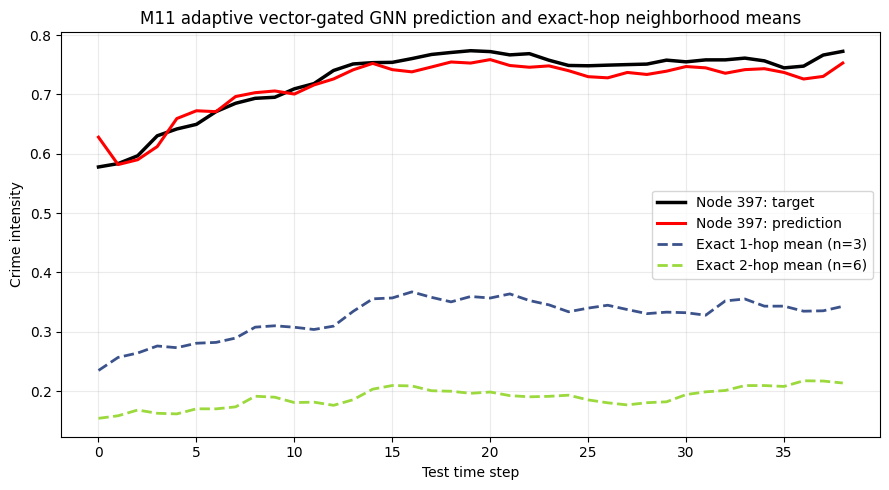

In [111]:
def adjacency_from_edge_index(edge_index, num_nodes):
    adjacency = {i: set() for i in range(num_nodes)}
    src, dst = edge_index.detach().cpu().numpy()
    for u, v in zip(src, dst):
        adjacency[int(u)].add(int(v))
        adjacency[int(v)].add(int(u))
    return adjacency


def exact_hop_nodes(center, adjacency, hop):
    visited = {center}
    frontier = {center}
    for _ in range(hop):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(adjacency.get(node, set()))
        next_frontier -= visited
        visited |= next_frontier
        frontier = next_frontier
    return sorted(frontier)


def plot_neighborhood_prediction(pred_matrix, target_matrix, center_node, adjacency,
                                 max_hop=2, output_path=None):
    time = np.arange(pred_matrix.shape[0])
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(time, target_matrix[:, center_node], color="black", linewidth=2.5,
            label=f"Node {center_node}: target")
    ax.plot(time, pred_matrix[:, center_node], color="red", linewidth=2.2,
            label=f"Node {center_node}: prediction")

    colors = plt.cm.viridis(np.linspace(0.25, 0.85, max_hop))
    for hop, color in zip(range(1, max_hop + 1), colors):
        nodes = exact_hop_nodes(center_node, adjacency, hop)
        if nodes:
            mean_series = pred_matrix[:, nodes].mean(axis=1)
            ax.plot(time, mean_series, linestyle="--", linewidth=2, color=color,
                    label=f"Exact {hop}-hop mean (n={len(nodes)})")

    ax.set(xlabel="Test time step", ylabel="Crime intensity",
           title="M11 adaptive vector-gated GNN prediction and exact-hop neighborhood means")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    if output_path:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


pred_matrix = np.stack(preds_per_t)
target_matrix = np.stack(targets_per_t)
sample_graph = test_dataset[0]
adjacency = adjacency_from_edge_index(sample_graph.edge_index, pred_matrix.shape[1])

# Select the node with the highest mean target crime in the test period.
selected_node = int(np.argmax(target_matrix.mean(axis=0)))
plot_neighborhood_prediction(
    pred_matrix, target_matrix, selected_node, adjacency, max_hop=2,
    output_path=os.path.join(output_folder, "m11_high_crime_node_neighborhood.png")
)


### Easy explanation — focal-node prediction and graph neighborhoods

**Purpose.** The black line is the selected high-crime node's true target, red is its
prediction, and dashed lines summarize predictions for nodes exactly one and two graph hops
away. This checks whether the focal node differs from its street-network surroundings.

The red prediction follows the black target closely, although it slightly underpredicts some
high values. One-hop and two-hop averages are much lower, showing that this selected street
segment is a local high-crime case relative to its neighbors.

**Caution.** This is one deliberately selected high-crime node. It is a useful example, not
evidence that hop averages must decrease for all nodes. The model should be evaluated using
the full test metrics, not this one curve.


# Prediction scatter and residual analysis


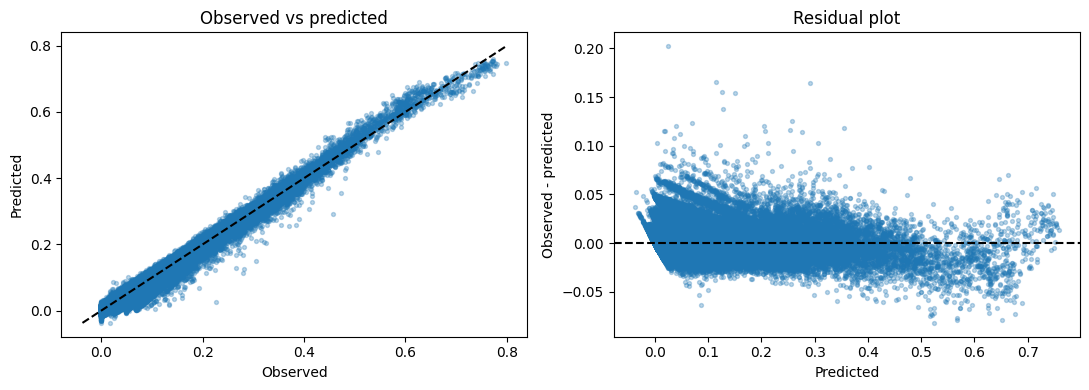

In [112]:
y_true = target_matrix.reshape(-1)
y_pred = pred_matrix.reshape(-1)
residual = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_true, y_pred, s=8, alpha=0.3)
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
axes[0].plot([lo, hi], [lo, hi], color="black", linestyle="--")
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(y_pred, residual, s=8, alpha=0.3)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(title="Residual plot", xlabel="Predicted", ylabel="Observed - predicted")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_prediction_diagnostics.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — observed/predicted and residual plots

**Left: observed versus predicted.** Perfect predictions would lie on the diagonal dashed
line. Most points are tightly concentrated around it, supporting the high R². At the highest
crime values, some points fall below the diagonal, indicating underprediction of extremes.

**Right: residuals.** Residual is `observed − predicted`. Values above zero mean
underprediction; values below zero mean overprediction. A perfect residual plot would be a
random narrow cloud around zero with equal spread everywhere. Here the spread changes with
prediction magnitude, so error variance is not completely constant.

**Conclusion.** Overall fit is strong, but high-crime cases remain more difficult. Reporting
MAE/RMSE by target-crime quantile would make this limitation clearer.


# M11 adaptive vector-gated GNN embedding projection


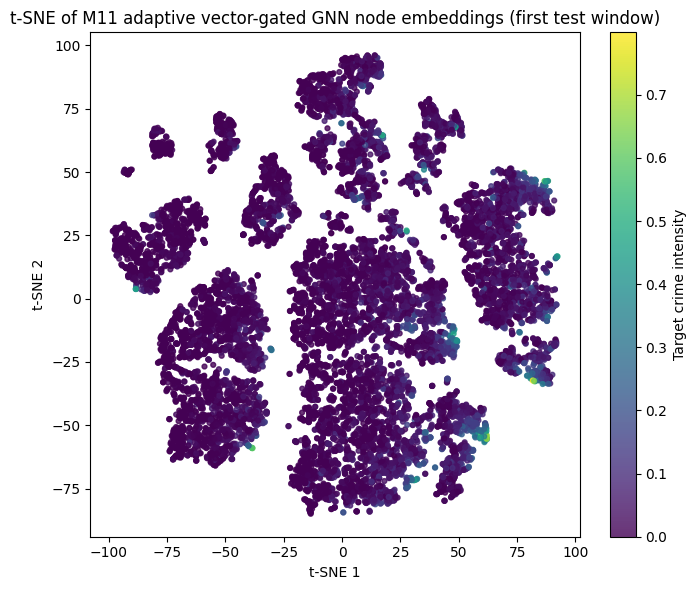

In [113]:
from sklearn.manifold import TSNE

# Use the first test window so that each plotted point corresponds to one node.
embedding = test_results["embeddings_per_time"][0].numpy()
target_first_window = targets_per_t[0]

if embedding.shape[0] >= 3:
    perplexity = min(30, max(2, (embedding.shape[0] - 1) // 3))
    embedding_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=seed,
    ).fit_transform(embedding)

    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        embedding_2d[:, 0], embedding_2d[:, 1],
        c=target_first_window, cmap="viridis", s=12, alpha=0.8
    )
    plt.colorbar(scatter, label="Target crime intensity")
    plt.title("t-SNE of M11 adaptive vector-gated GNN node embeddings (first test window)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "m11_embedding_tsne.png"), dpi=300, bbox_inches="tight")
    plt.show()

    pd.DataFrame(embedding_2d, columns=["tsne_1", "tsne_2"]).to_csv(
        os.path.join(output_folder, "m11_embedding_tsne.csv"), index=False
    )
else:
    print("At least three nodes are required for t-SNE.")


### Easy explanation — t-SNE of learned embeddings

**Purpose.** The model converts each node into a 64-dimensional hidden representation.
t-SNE projects those representations into two dimensions so local group structure can be
visualized. Color indicates target crime intensity.

The points form many distinct local groups, so the embeddings have not collapsed to one
identical representation. Most cases are low crime, while some high-crime cases occupy
localized regions.

**Limitation.** t-SNE is a visualization, not a performance test. It preserves local
neighborhoods approximately, but distances between distant clusters, cluster sizes, and axes
do not have direct quantitative meanings. It cannot by itself prove that one model is better.


# Interpretation notes

- Self and neighbor gates are separate GMU-style feature-wise vectors.
- Their values change across nodes, time windows, and latent dimensions.
- The neighbor gate depends on the source node and time window; it is shared
  across that node's outgoing edges and is not target-specific attention.
- Gate means are learned mixing summaries, not causal importance measures.
- For comparison with GMU-GNN, keep the split, hidden dimension, training
  budget, loss, aggregation, and random seeds identical.


# Publication-oriented explainability and gate validation suite

The previous analyses are preserved unchanged. This appendix adds complementary
diagnostics that answer different questions about the proposed two-gate model.

| Analysis family | Main question | Evidence type |
|---|---|---|
| Gate distributions and entropy | Did the gates collapse or saturate? | Descriptive |
| Feature-wise specialization | Does averaging hide latent gate structure? | Descriptive |
| Gate–crime association | Does modality balance vary with crime intensity? | Associational |
| Effective activation contribution | How much gated activation enters fusion? | Mechanistic summary |
| Self-versus-neighbor comparison | Do the two message roles learn different balances? | Proposed-model specific |
| Spatial and temporal stability | Are learned patterns stable across nodes and time? | Robustness |
| Gate–error relationship | Is modality selection associated with prediction difficulty? | Diagnostic |
| Gate intervention | Does changing the learned gate harm prediction? | Faithfulness |
| Input permutation importance | Which original variables affect performance? | Model-agnostic faithfulness |
| Bootstrap confidence intervals | How uncertain are reported summaries? | Statistical uncertainty |

Gate coefficients are not automatically explanations. The strongest defense combines
gate inspection with activation magnitude, interventions, ablations, permutation
importance, and repeated-seed stability.


## A. Rich node-time explainability collection


In [114]:
import contextlib
import math
import warnings

try:
    from scipy.stats import pearsonr, spearmanr, wilcoxon
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    warnings.warn("SciPy is unavailable; p-values and Wilcoxon tests will be skipped.")


def _expand_case_metadata(value, n, fallback, device):
    if value is None:
        value = torch.tensor(fallback, device=device)
    value = value.reshape(-1)
    if value.numel() == 1 and n > 1:
        value = value.repeat(n)
    if value.numel() != n:
        raise ValueError(f"Metadata length {value.numel()} does not match node count {n}.")
    return value


@torch.no_grad()
def collect_rich_explainability(model, loader, device):
    # Collect gates, projections, gated activation magnitudes, errors, IDs and time.
    model.eval()
    rows = []
    self_vectors, neighbor_vectors = [], []

    for step, data in enumerate(loader):
        data = data.to(device)
        prediction, _, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        prediction = prediction.reshape(-1)
        target = data.y.float().view_as(prediction)
        n = prediction.numel()

        node_ids = _expand_case_metadata(
            getattr(data, "node_ids", None), n, torch.arange(n, device=device), device
        )
        time_ids = _expand_case_metadata(
            getattr(data, "time_id", None), n, step, device
        )

        # These helpers reproduce the exact projections and gates used by the model.
        self_stat, self_dyn, self_gate = model.gnn._self_components(
            data.x_static, data.x_dynamic
        )
        neigh_stat, neigh_dyn, neigh_gate = model.gnn._neighbor_components(
            data.x_static, data.x_dynamic
        )

        self_static_component = self_gate * self_stat
        self_dynamic_component = (1.0 - self_gate) * self_dyn
        neigh_static_component = neigh_gate * neigh_stat
        neigh_dynamic_component = (1.0 - neigh_gate) * neigh_dyn

        self_static_mag = torch.linalg.vector_norm(self_static_component, dim=1)
        self_dynamic_mag = torch.linalg.vector_norm(self_dynamic_component, dim=1)
        neigh_static_mag = torch.linalg.vector_norm(neigh_static_component, dim=1)
        neigh_dynamic_mag = torch.linalg.vector_norm(neigh_dynamic_component, dim=1)

        eps = 1e-12
        self_static_prop = self_static_mag / (self_static_mag + self_dynamic_mag + eps)
        neigh_static_prop = neigh_static_mag / (neigh_static_mag + neigh_dynamic_mag + eps)

        batch_frame = pd.DataFrame({
            "node_id": node_ids.cpu().numpy(),
            "time_id": time_ids.cpu().numpy(),
            "input_crime": data.x_dynamic.mean(dim=1).cpu().numpy(),
            "target_crime": target.cpu().numpy(),
            "prediction": prediction.cpu().numpy(),
            "residual": (target - prediction).cpu().numpy(),
            "absolute_error": (target - prediction).abs().cpu().numpy(),
            "self_static_gate": self_gate.mean(dim=1).cpu().numpy(),
            "neighbor_static_gate": neigh_gate.mean(dim=1).cpu().numpy(),
            "self_static_activation": self_static_mag.cpu().numpy(),
            "self_dynamic_activation": self_dynamic_mag.cpu().numpy(),
            "neighbor_static_activation": neigh_static_mag.cpu().numpy(),
            "neighbor_dynamic_activation": neigh_dynamic_mag.cpu().numpy(),
            "self_static_activation_proportion": self_static_prop.cpu().numpy(),
            "neighbor_static_activation_proportion": neigh_static_prop.cpu().numpy(),
        })
        rows.append(batch_frame)
        self_vectors.append(self_gate.cpu())
        neighbor_vectors.append(neigh_gate.cpu())

    frame = pd.concat(rows, ignore_index=True)
    vectors = {
        "self": torch.cat(self_vectors).numpy(),
        "neighbor": torch.cat(neighbor_vectors).numpy(),
    }
    return frame, vectors


explain_frame, gate_vectors = collect_rich_explainability(
    model, test_loader, device
)
print("Explainability cases:", len(explain_frame))
print("Gate vector shape:", gate_vectors["self"].shape)
display(explain_frame.head())


Explainability cases: 570960
Gate vector shape: (570960, 64)


,node_id,time_id,input_crime,target_crime,prediction,residual,absolute_error,self_static_gate,neighbor_static_gate,self_static_activation,self_dynamic_activation,neighbor_static_activation,neighbor_dynamic_activation,self_static_activation_proportion,neighbor_static_activation_proportion
0,0,100,0.126909,0.136371,0.108647,0.027724,0.027724,0.471684,0.489793,3.810100,4.356815,4.454181,3.832179,0.466529,0.537532
1,1,100,0.109170,0.097192,0.099960,-0.002768,0.002768,0.462262,0.494631,3.593708,4.522435,4.577809,3.794894,0.442785,0.546754
2,2,100,0.161374,0.125887,0.138950,-0.013063,0.013063,0.463875,0.488060,3.755238,4.503563,4.468492,3.816265,0.454695,0.539363
3,3,100,0.096176,0.097884,0.088810,0.009075,0.009075,0.472881,0.494465,3.807668,4.365934,4.475480,3.803081,0.465849,0.540611
4,4,100,0.014133,0.041428,0.040699,0.000729,0.000729,0.480962,0.513002,4.011617,3.645443,4.784597,3.925695,0.523911,0.549304


### Easy explanation — collected explainability table

**Purpose.** This table places everything needed for later analyses into one row per
node-time case: IDs, crime inputs, target, prediction, error, gates, activation magnitudes,
and effective proportions. There are **570,960 cases**, and each self/neighbor gate has
**64 dimensions**.

For example, `self_static_gate` is the average of the 64 self gate dimensions for one case.
`self_static_activation_proportion` additionally considers how large the gated static and
dynamic vectors are. These two quantities answer different questions and should not be
treated as interchangeable.


## B. Gate health: variation, entropy and saturation

A global mean near 0.5 is not necessarily a problem. This section tests whether
individual gates vary, whether they remain uncertain around 0.5, and whether they
saturate near 0 or 1. Low variation plus no faithfulness benefit is more consistent
with gate collapse than a mean of 0.5 alone.


,role,global_mean,global_std,case_mean_std,q05,median,q95,minimum,maximum,mean_entropy_0_to_1,fraction_below_0.10,fraction_above_0.90,fraction_near_balanced_0.45_0.55
0,self,0.4895,0.2853,0.0119,0.0411,0.4560,0.9839,0.0065,1.0000,0.7193,0.1088,0.1257,0.1194
1,neighbor,0.4815,0.2017,0.0118,0.1407,0.4685,0.7997,0.0352,0.9843,0.8724,0.0182,0.0130,0.1648


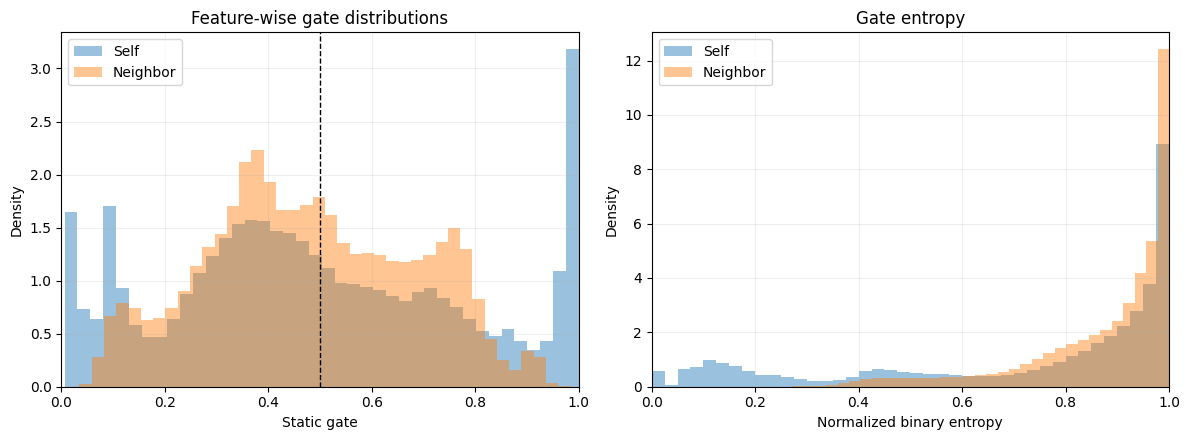

In [115]:
def binary_gate_entropy(gates, eps=1e-8):
    g = np.clip(np.asarray(gates), eps, 1.0-eps)
    return -(g*np.log(g) + (1.0-g)*np.log(1.0-g)) / np.log(2.0)


def gate_health_table(gate_vectors):
    records = []
    for role, values in gate_vectors.items():
        flat = values.reshape(-1)
        case_mean = values.mean(axis=1)
        entropy = binary_gate_entropy(flat)
        records.append({
            "role": role,
            "global_mean": flat.mean(),
            "global_std": flat.std(),
            "case_mean_std": case_mean.std(),
            "q05": np.quantile(flat, 0.05),
            "median": np.median(flat),
            "q95": np.quantile(flat, 0.95),
            "minimum": flat.min(),
            "maximum": flat.max(),
            "mean_entropy_0_to_1": entropy.mean(),
            "fraction_below_0.10": np.mean(flat < 0.10),
            "fraction_above_0.90": np.mean(flat > 0.90),
            "fraction_near_balanced_0.45_0.55": np.mean((flat >= 0.45) & (flat <= 0.55)),
        })
    return pd.DataFrame(records)


gate_health = gate_health_table(gate_vectors)
display(gate_health.round(4))
gate_health.to_csv(os.path.join(output_folder, "professional_gate_health.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for role, color in [("self", "tab:blue"), ("neighbor", "tab:orange")]:
    axes[0].hist(gate_vectors[role].reshape(-1), bins=40, density=True,
                 alpha=0.45, color=color, label=role.title())
    axes[1].hist(binary_gate_entropy(gate_vectors[role]).reshape(-1), bins=40,
                 density=True, alpha=0.45, color=color, label=role.title())
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set(title="Feature-wise gate distributions", xlabel="Static gate", ylabel="Density", xlim=(0, 1))
axes[1].set(title="Gate entropy", xlabel="Normalized binary entropy", ylabel="Density", xlim=(0, 1))
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_gate_health.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — gate health, entropy and saturation

**Purpose.** This tests whether the gate has collapsed, remains completely indecisive, or has
learned different choices across latent dimensions.

- `global_mean`: average static gate over all cases and dimensions.
- `global_std`: feature-wise variation; larger values mean dimensions make different choices.
- `case_mean_std`: variation after averaging 64 dimensions for each case.
- `q05/q95`: 90% of gate values lie between these limits.
- `entropy`: 1 means a gate near 0.5; 0 means a gate near 0 or 1.
- saturation fractions: proportions near the static or dynamic extremes.

The self gate has mean 0.4895 but high standard deviation **0.2853**, entropy **0.719**, and
about 10.9% of values below 0.1 plus 12.6% above 0.9. The neighbor gate is softer
(standard deviation 0.2017 and entropy 0.872). Only 11.9% of self values and 16.5% of neighbor
values lie near 0.5.

**Conclusion.** The gate has not collapsed to one constant value. The self pathway makes more
specialized feature-wise choices than the neighbor pathway. Extremeness itself is not proof
of correctness; intervention and predictive analyses must support it.


## C. Feature-wise specialization

The gate has shape $N\times H$. Averaging over $H$ can hide dimensions that move
in opposite directions. These plots show each latent gate dimension's mean,
variability, and association with crime.


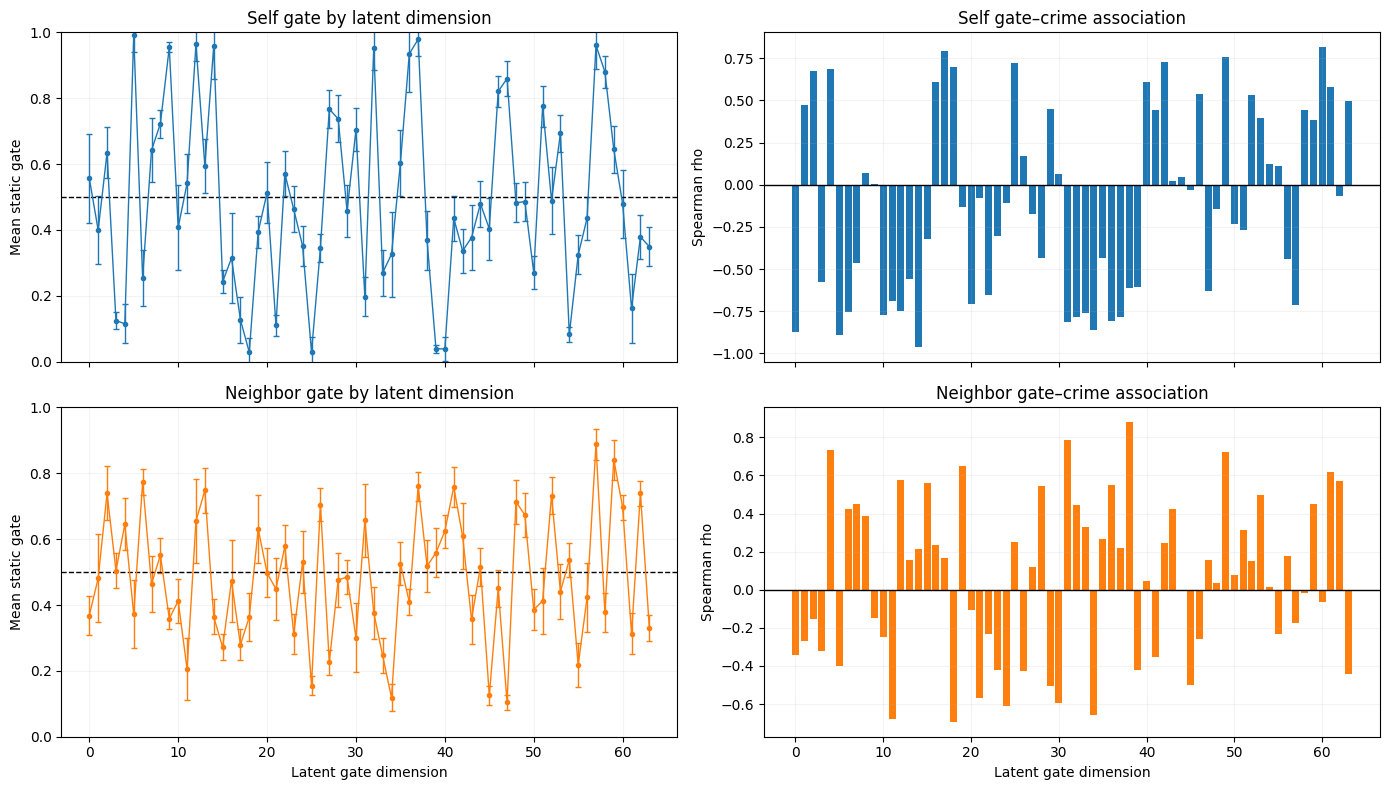

,role,dimension,mean_gate,std_gate,crime_spearman_rho,crime_spearman_p
14,self,14,0.958803,0.099783,-0.959575,0.0
5,self,5,0.991583,0.051554,-0.890387,0.0
102,neighbor,38,0.518211,0.078998,0.878176,0.0
0,self,0,0.557005,0.135617,-0.874486,0.0
34,self,34,0.326269,0.129432,-0.862500,0.0
60,self,60,0.478957,0.103911,0.814502,0.0
31,self,31,0.197139,0.059365,-0.811836,0.0
36,self,36,0.934845,0.114738,-0.806743,0.0
17,self,17,0.127319,0.069770,0.791363,0.0
95,neighbor,31,0.656679,0.110657,0.786138,0.0


In [116]:
def safe_correlations(x, matrix, method="spearman"):
    x = np.asarray(x)
    values = []
    pvalues = []
    for k in range(matrix.shape[1]):
        y = matrix[:, k]
        if np.std(x) == 0 or np.std(y) == 0:
            values.append(np.nan)
            pvalues.append(np.nan)
        elif SCIPY_AVAILABLE:
            result = spearmanr(x, y) if method == "spearman" else pearsonr(x, y)
            values.append(float(result[0]))
            pvalues.append(float(result[1]))
        else:
            values.append(float(np.corrcoef(x, y)[0, 1]))
            pvalues.append(np.nan)
    return np.asarray(values), np.asarray(pvalues)


crime_values = explain_frame["input_crime"].to_numpy()
feature_records = []
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex="col")

for row, (role, color) in enumerate([("self", "tab:blue"), ("neighbor", "tab:orange")]):
    values = gate_vectors[role]
    means = values.mean(axis=0)
    stds = values.std(axis=0)
    rho, pval = safe_correlations(crime_values, values, method="spearman")
    dims = np.arange(values.shape[1])

    axes[row, 0].errorbar(dims, means, yerr=stds, marker="o", markersize=3,
                          linewidth=1, capsize=2, color=color)
    axes[row, 0].axhline(0.5, color="black", linestyle="--", linewidth=1)
    axes[row, 0].set(title=f"{role.title()} gate by latent dimension",
                     ylabel="Mean static gate", ylim=(0, 1))

    axes[row, 1].bar(dims, rho, color=color)
    axes[row, 1].axhline(0, color="black", linewidth=1)
    axes[row, 1].set(title=f"{role.title()} gate–crime association",
                     ylabel="Spearman rho")

    for k in dims:
        feature_records.append({
            "role": role, "dimension": int(k), "mean_gate": means[k],
            "std_gate": stds[k], "crime_spearman_rho": rho[k],
            "crime_spearman_p": pval[k],
        })

axes[1, 0].set_xlabel("Latent gate dimension")
axes[1, 1].set_xlabel("Latent gate dimension")
for ax in axes.ravel():
    ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_featurewise_gate_specialization.png"), dpi=300, bbox_inches="tight")
plt.show()

featurewise_gate_stats = pd.DataFrame(feature_records)
featurewise_gate_stats.to_csv(os.path.join(output_folder, "professional_featurewise_gate_stats.csv"), index=False)
display(featurewise_gate_stats.reindex(featurewise_gate_stats.crime_spearman_rho.abs().sort_values(ascending=False).index).head(10))


### Easy explanation — feature-wise gate specialization

**Purpose.** The model has 64 gate dimensions. This analysis asks whether some hidden
dimensions favor static information while others favor dynamic information, and whether
those preferences change with crime.

The left plots show each dimension's mean gate and variability. The right plots show
Spearman correlation between that dimension and crime. Positive correlation means the
dimension becomes more static as crime rises; negative means it becomes more dynamic.

Examples are very strong: self dimension 14 has mean gate 0.959 but correlation −0.960,
meaning it is usually static-weighted yet shifts sharply toward dynamic information for
higher-crime cases. Neighbor dimension 38 has correlation +0.878, showing the opposite
crime-dependent direction.

**Conclusion.** A global mean near 0.5 hides substantial specialization. However, dimension
14 is a learned latent dimension—not a named socioeconomic variable. These correlations
must be checked across random seeds and should not be called causal relationships.


## D. Gate association with input and future crime

Pearson measures linear association; Spearman measures monotonic association.
Correlations are computed on all original node-time cases. Binning is used only
for visualization, preventing smoothed bin means from inflating the reported
association.


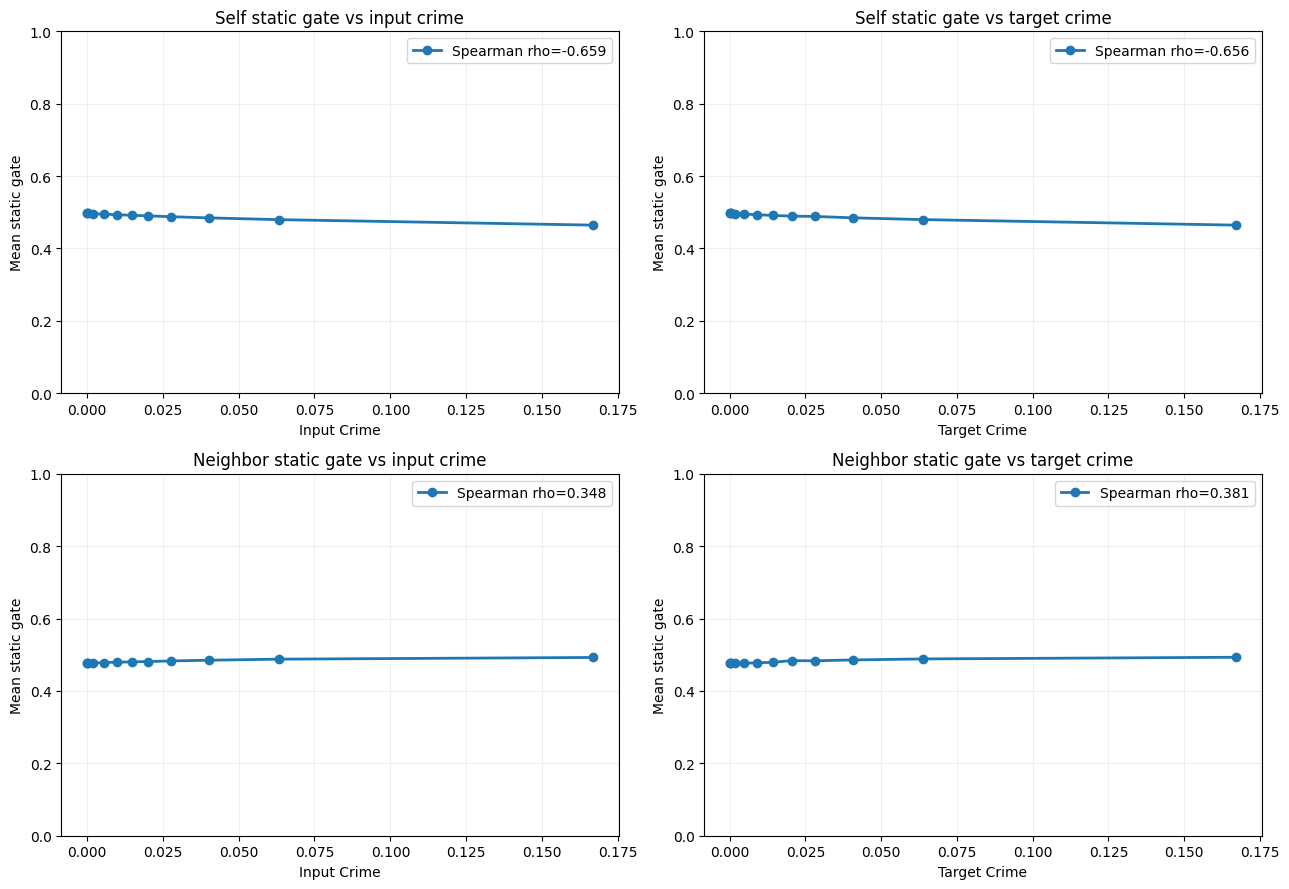

,role,crime_variable,pearson_r,pearson_p,spearman_rho,spearman_p
0,Self,input_crime,-0.76286,0.0,-0.65909,0.0
1,Self,target_crime,-0.76344,0.0,-0.65598,0.0
2,Neighbor,input_crime,0.34232,0.0,0.34808,0.0
3,Neighbor,target_crime,0.36633,0.0,0.38109,0.0


In [117]:
def association_stats(x, y):
    x, y = np.asarray(x), np.asarray(y)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return {"pearson_r": np.nan, "pearson_p": np.nan,
                "spearman_rho": np.nan, "spearman_p": np.nan}
    if SCIPY_AVAILABLE:
        pr, sr = pearsonr(x, y), spearmanr(x, y)
        return {"pearson_r": float(pr[0]), "pearson_p": float(pr[1]),
                "spearman_rho": float(sr[0]), "spearman_p": float(sr[1])}
    return {"pearson_r": float(np.corrcoef(x, y)[0, 1]), "pearson_p": np.nan,
            "spearman_rho": np.nan, "spearman_p": np.nan}


def binned_summary(frame, x_col, y_col, bins=12):
    work = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work["bin"] = pd.qcut(work[x_col], q=bins, duplicates="drop")
    out = work.groupby("bin", observed=True).agg(
        mean_x=(x_col, "mean"), mean_y=(y_col, "mean"),
        std_y=(y_col, "std"), count=(y_col, "size")
    ).reset_index(drop=True)
    out["ci95"] = 1.96*out["std_y"] / np.sqrt(out["count"].clip(lower=1))
    return out


association_rows = []
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, gate_col in enumerate(["self_static_gate", "neighbor_static_gate"]):
    role = "Self" if gate_col.startswith("self") else "Neighbor"
    for col, x_col in enumerate(["input_crime", "target_crime"]):
        stats = association_stats(explain_frame[x_col], explain_frame[gate_col])
        association_rows.append({"role": role, "crime_variable": x_col, **stats})
        summary = binned_summary(explain_frame, x_col, gate_col, bins=12)
        ax = axes[row, col]
        ax.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2)
        ax.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                        summary["mean_y"]+summary["ci95"], alpha=0.2)
        ax.set(title=f"{role} static gate vs {x_col.replace('_', ' ')}",
               xlabel=x_col.replace("_", " ").title(), ylabel="Mean static gate", ylim=(0, 1))
        ax.legend([f"Spearman rho={stats['spearman_rho']:.3f}"], loc="best")
        ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_gate_crime_associations.png"), dpi=300, bbox_inches="tight")
plt.show()

gate_crime_associations = pd.DataFrame(association_rows)
display(gate_crime_associations.round(5))
gate_crime_associations.to_csv(os.path.join(output_folder, "professional_gate_crime_associations.csv"), index=False)


### Easy explanation — average gates versus crime

**Purpose.** This asks whether the overall modality balance changes with crime intensity.
Pearson measures a straight-line relationship; Spearman measures whether one quantity tends
to rise or fall monotonically with the other.

Self gate correlations are strongly negative: Spearman **−0.659** for input crime and
**−0.656** for future target crime. Therefore, as crime rises, the focal node's self pathway
places more weight on dynamic crime history.

Neighbor correlations are moderately positive: **0.348** and **0.381**. Therefore, as crime
rises, neighborhood messages place somewhat more weight on static context.

**Main interpretation.** The two roles respond differently: high-crime focal predictions
become more dynamic, while their incoming neighborhood representation becomes relatively
more static. This is strong support for role-specific fusion, but it is association—not proof
that crime causes the gates to move.


## E. Effective gated activation contribution

Gate values alone ignore the magnitude of projected modality representations.
For example, a gate of 0.5 can still yield a much larger dynamic contribution if
the dynamic projection has greater norm. The normalized activation proportions
below are therefore stronger mechanistic summaries than raw gates alone.


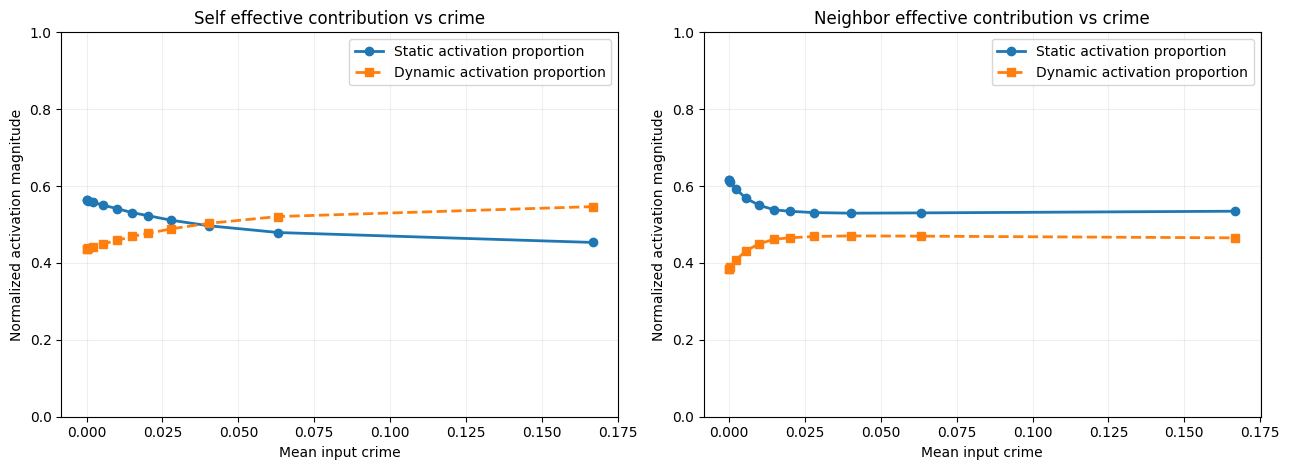

,role,mean_raw_static_gate,mean_effective_static_proportion,mean_effective_dynamic_proportion,gate_vs_effective_pearson
0,self,0.4895,0.5276,0.4724,0.8800
1,neighbor,0.4815,0.5625,0.4375,-0.0314


In [118]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
contribution_rows = []

for ax, role in zip(axes, ["self", "neighbor"]):
    gate_col = f"{role}_static_gate"
    prop_col = f"{role}_static_activation_proportion"
    summary = binned_summary(explain_frame, "input_crime", prop_col, bins=12)
    ax.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2,
            label="Static activation proportion")
    ax.plot(summary["mean_x"], 1.0-summary["mean_y"], marker="s", linestyle="--",
            linewidth=2, label="Dynamic activation proportion")
    ax.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                    summary["mean_y"]+summary["ci95"], alpha=0.15)
    ax.set(title=f"{role.title()} effective contribution vs crime",
           xlabel="Mean input crime", ylabel="Normalized activation magnitude", ylim=(0, 1))
    ax.legend()
    ax.grid(alpha=0.2)
    contribution_rows.append({
        "role": role,
        "mean_raw_static_gate": explain_frame[gate_col].mean(),
        "mean_effective_static_proportion": explain_frame[prop_col].mean(),
        "mean_effective_dynamic_proportion": 1.0-explain_frame[prop_col].mean(),
        "gate_vs_effective_pearson": association_stats(explain_frame[gate_col], explain_frame[prop_col])["pearson_r"],
    })

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_effective_activation_contribution.png"), dpi=300, bbox_inches="tight")
plt.show()

effective_contribution_summary = pd.DataFrame(contribution_rows)
display(effective_contribution_summary.round(4))
effective_contribution_summary.to_csv(os.path.join(output_folder, "professional_effective_contribution.csv"), index=False)


### Easy explanation — effective activation contribution

**Why is this analysis needed?** A gate of 0.5 does not guarantee equal actual contribution.
If one projected modality vector is much larger, it can still dominate. This analysis measures
the norms of `gate × static vector` and `(1−gate) × dynamic vector`.

Self effective contribution is **52.8% static / 47.2% dynamic**. Neighbor contribution is
**56.2% static / 43.8% dynamic**. These are reasonably balanced and confirm that LayerNorm
removed the previous severe 94–96% static magnitude dominance.

For self information, raw gate and effective contribution correlate strongly (**r=0.880**),
so higher self static gates generally correspond to more static activation. For neighbors,
correlation is near zero (**−0.031**); neighbor aggregation and dimension-level magnitudes
make its average gate a poor direct proxy for effective contribution.

**Conclusion.** LayerNorm achieved its intended scale-balancing purpose. Activation magnitude
still does not equal predictive importance; ablation, interventions, and permutation answer
that question more directly.


## F. Self-versus-neighbor role separation

This is the analysis most specific to the proposed architecture. If self and
neighbor gates learn different distributions, the two-gate design captures a
distinction that a standard one-gate GMU cannot represent.


,mean_self_static_gate,mean_neighbor_static_gate,mean_paired_difference,paired_difference_std,cohen_dz,fraction_self_more_static,self_neighbor_pearson_r,wilcoxon_statistic,wilcoxon_p
0,0.48947,0.48146,0.00801,0.02145,0.37348,0.6908,-0.62935,4.520902e+10,0.0


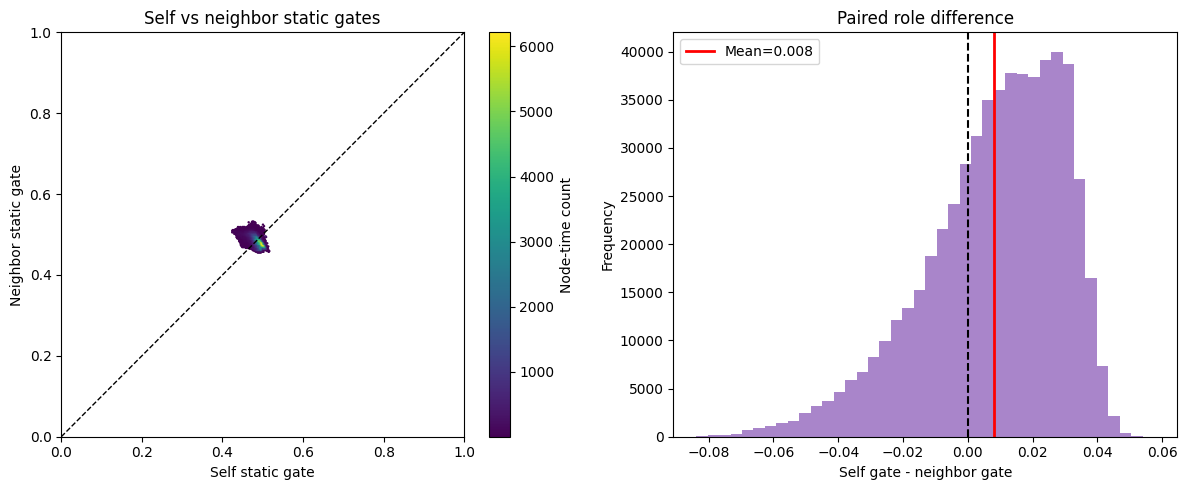

In [119]:
self_gate_values = explain_frame["self_static_gate"].to_numpy()
neighbor_gate_values = explain_frame["neighbor_static_gate"].to_numpy()
role_difference = self_gate_values - neighbor_gate_values

role_stats = association_stats(self_gate_values, neighbor_gate_values)
role_summary = {
    "mean_self_static_gate": self_gate_values.mean(),
    "mean_neighbor_static_gate": neighbor_gate_values.mean(),
    "mean_paired_difference": role_difference.mean(),
    "paired_difference_std": role_difference.std(ddof=1),
    "cohen_dz": role_difference.mean()/(role_difference.std(ddof=1)+1e-12),
    "fraction_self_more_static": np.mean(role_difference > 0),
    "self_neighbor_pearson_r": role_stats["pearson_r"],
}
if SCIPY_AVAILABLE and np.any(role_difference != 0):
    test = wilcoxon(self_gate_values, neighbor_gate_values)
    role_summary["wilcoxon_statistic"] = float(test[0])
    role_summary["wilcoxon_p"] = float(test[1])
else:
    role_summary["wilcoxon_statistic"] = np.nan
    role_summary["wilcoxon_p"] = np.nan

display(pd.DataFrame([role_summary]).round(5))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
hb = axes[0].hexbin(self_gate_values, neighbor_gate_values, gridsize=35,
                    cmap="viridis", mincnt=1)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set(title="Self vs neighbor static gates", xlabel="Self static gate",
            ylabel="Neighbor static gate", xlim=(0, 1), ylim=(0, 1))
fig.colorbar(hb, ax=axes[0], label="Node-time count")
axes[1].hist(role_difference, bins=40, color="tab:purple", alpha=0.8)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].axvline(role_difference.mean(), color="red", linewidth=2,
                label=f"Mean={role_difference.mean():.3f}")
axes[1].set(title="Paired role difference", xlabel="Self gate - neighbor gate", ylabel="Frequency")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_self_neighbor_role_separation.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — self versus neighbor role separation

**Purpose.** This tests the core architectural claim: do self information and neighbor
messages learn different modality-selection behavior?

Mean self static gate is 0.48947 and neighbor is 0.48146, a difference of **0.00801**
(0.8 percentage points). Cohen's dz is **0.373**, a small-to-moderate standardized paired
difference. Self is more static than neighbor in **69.1%** of cases.

The correlation between self and neighbor gates is **−0.629**. This negative relationship is
more informative than the small mean gap: cases shifting self toward static often shift
neighbor toward dynamic, and vice versa. The tiny Wilcoxon p-value is expected with 570,960
cases; effect size and consistency matter more than p-value.

**Conclusion.** Role separation is present mainly in their opposite case-by-case behavior,
not in a large difference between their global means.


## G. Spatial and temporal stability


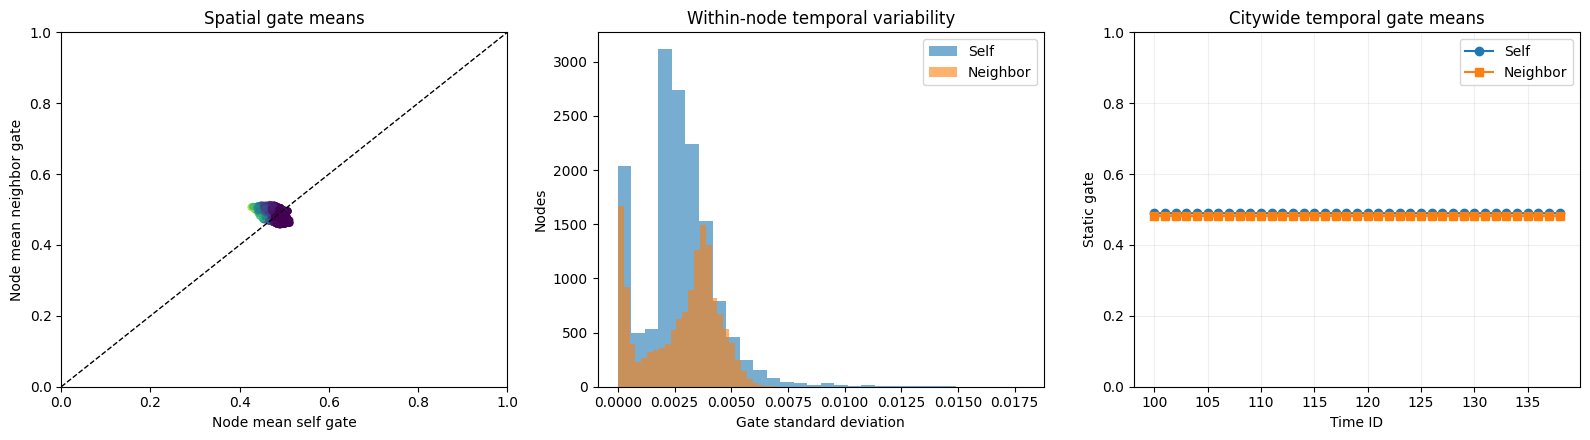

,node_id,self_mean,self_std,neighbor_mean,neighbor_std,mean_crime,mean_absolute_error
2538,2538,0.466407,0.017887,0.474352,0.005306,0.227495,0.033313
10680,10680,0.470833,0.017268,0.482861,0.006387,0.170078,0.014903
5855,5855,0.472202,0.017208,0.488088,0.005186,0.167380,0.015975
122,122,0.447250,0.016276,0.511594,0.003767,0.189875,0.014155
6697,6697,0.472035,0.016268,0.482095,0.006446,0.173620,0.015778
1423,1423,0.448775,0.015217,0.500949,0.003272,0.285412,0.018570
6693,6693,0.454929,0.015049,0.484721,0.003097,0.244658,0.020297
692,692,0.479063,0.014831,0.486583,0.005395,0.109364,0.011446
3852,3852,0.457525,0.014593,0.501789,0.001246,0.219688,0.009110
9763,9763,0.462371,0.014403,0.508008,0.004471,0.145622,0.014590


In [120]:
node_stability = explain_frame.groupby("node_id").agg(
    self_mean=("self_static_gate", "mean"),
    self_std=("self_static_gate", "std"),
    neighbor_mean=("neighbor_static_gate", "mean"),
    neighbor_std=("neighbor_static_gate", "std"),
    mean_crime=("input_crime", "mean"),
    mean_absolute_error=("absolute_error", "mean"),
).reset_index()

time_stability = explain_frame.groupby("time_id").agg(
    self_mean=("self_static_gate", "mean"),
    self_std=("self_static_gate", "std"),
    neighbor_mean=("neighbor_static_gate", "mean"),
    neighbor_std=("neighbor_static_gate", "std"),
    mean_crime=("input_crime", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(node_stability["self_mean"], node_stability["neighbor_mean"],
                c=node_stability["mean_crime"], cmap="viridis", s=18, alpha=0.7)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set(title="Spatial gate means", xlabel="Node mean self gate",
            ylabel="Node mean neighbor gate", xlim=(0, 1), ylim=(0, 1))

axes[1].hist(node_stability["self_std"].dropna(), bins=30, alpha=0.6, label="Self")
axes[1].hist(node_stability["neighbor_std"].dropna(), bins=30, alpha=0.6, label="Neighbor")
axes[1].set(title="Within-node temporal variability", xlabel="Gate standard deviation", ylabel="Nodes")
axes[1].legend()

axes[2].plot(time_stability["time_id"], time_stability["self_mean"], marker="o", label="Self")
axes[2].plot(time_stability["time_id"], time_stability["neighbor_mean"], marker="s", label="Neighbor")
axes[2].set(title="Citywide temporal gate means", xlabel="Time ID", ylabel="Static gate", ylim=(0, 1))
axes[2].legend()
axes[2].grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_spatial_temporal_gate_stability.png"), dpi=300, bbox_inches="tight")
plt.show()

node_stability.to_csv(os.path.join(output_folder, "professional_node_gate_stability.csv"), index=False)
time_stability.to_csv(os.path.join(output_folder, "professional_time_gate_stability.csv"), index=False)
display(node_stability.sort_values("self_std", ascending=False).head(10))


### Easy explanation — spatial and temporal stability

**Purpose.** A useful gate should not be random noise. This analysis checks average behavior
across nodes, variability within each node over time, and citywide temporal behavior.

The node means occupy a relatively narrow area, while within-node self variability can reach
about 0.018 for the most variable nodes. Neighbor variability is generally smaller. The
citywide means remain nearly flat because local changes cancel when averaged over all nodes.

**How to interpret it.** The model has some node-specific temporal adaptation, especially in
self gates, but no strong citywide regime change. Stability is good for reproducibility;
complete flatness would be concerning only if intervention and feature-wise analyses also
showed no adaptation—which is not the case here.


## H. Gate relationship with prediction error

This diagnostic tests whether certain modality balances occur on easier or harder
cases. It does not establish that a gate value causes an error, but it can reveal
failure regimes and support qualitative case selection.


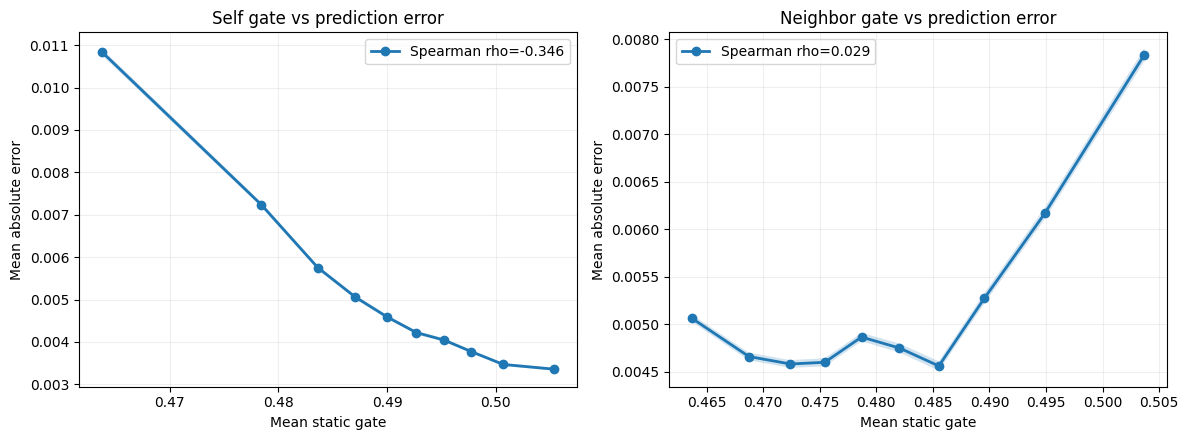

,role,pearson_r,pearson_p,spearman_rho,spearman_p
0,Self,-0.36000,0.0,-0.34591,0.0
1,Neighbor,0.12564,0.0,0.02866,0.0


In [121]:
error_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, gate_col in zip(axes, ["self_static_gate", "neighbor_static_gate"]):
    role = "Self" if gate_col.startswith("self") else "Neighbor"
    stats = association_stats(explain_frame[gate_col], explain_frame["absolute_error"])
    error_rows.append({"role": role, **stats})
    summary = binned_summary(explain_frame, gate_col, "absolute_error", bins=10)
    ax.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2)
    ax.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                    summary["mean_y"]+summary["ci95"], alpha=0.2)
    ax.set(title=f"{role} gate vs prediction error",
           xlabel="Mean static gate", ylabel="Mean absolute error")
    ax.legend([f"Spearman rho={stats['spearman_rho']:.3f}"])
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_gate_error_relationship.png"), dpi=300, bbox_inches="tight")
plt.show()

gate_error_association = pd.DataFrame(error_rows)
display(gate_error_association.round(5))
gate_error_association.to_csv(os.path.join(output_folder, "professional_gate_error_association.csv"), index=False)


### Easy explanation — gates versus prediction error

**Purpose.** This asks whether particular modality balances tend to occur on easy or difficult
predictions. It helps identify failure regimes; it does not show that a gate value causes the
error.

For the self pathway, Spearman correlation is **−0.346**: cases with higher self static gates
tend to have smaller errors. For the neighbor gate, Spearman is only **0.029**, which is
practically very weak despite the tiny p-value.

Crime magnitude may confound the self relationship: high crime lowers the self static gate
and high-crime cases may also be harder. A stronger follow-up is to repeat this analysis
within low-, medium-, and high-crime groups.


## I. Gate intervention faithfulness test

This is one of the strongest post-training explainability checks. It keeps all
trained weights fixed and intervenes only on gate logits. If learned gates are
useful, replacing them with balanced, static-heavy, dynamic-heavy, role-swapped,
or shuffled gates should generally worsen prediction. These are diagnostic
interventions, not retrained competing models.


,intervention,MSE,RMSE,MAE,delta_MSE_vs_learned,relative_MSE_change_percent
0,Learned gates,0.00006,0.00804,0.00523,0.00000,0.00000
1,"Balanced gates (0.5, 0.5)",0.03546,0.18831,0.14533,0.03540,54701.65424
2,"Static-heavy gates (0.95, 0.95)",0.18609,0.43138,0.40139,0.18603,287479.06504
3,"Dynamic-heavy gates (0.05, 0.05)",0.11587,0.34040,0.32231,0.11581,178964.66517
4,Self static / neighbor dynamic,0.07384,0.27173,0.24141,0.07377,114007.00073
5,Self dynamic / neighbor static,0.07864,0.28043,0.23393,0.07858,121429.26002
6,Shuffled learned gate logits,0.00360,0.06000,0.04363,0.00354,5463.06686


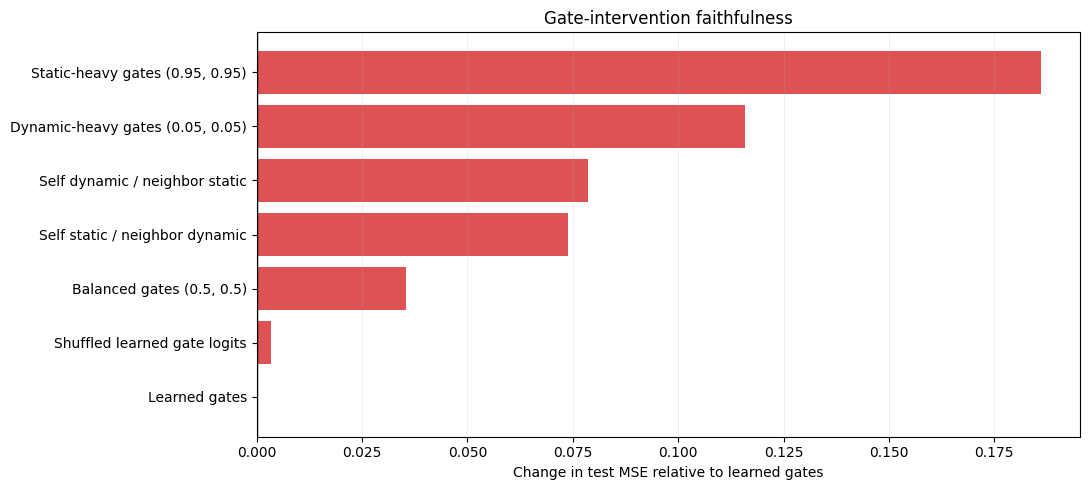

In [122]:
def _constant_logit_hook(probability):
    p = float(np.clip(probability, 1e-4, 1.0-1e-4))
    logit = math.log(p/(1.0-p))
    def hook(module, inputs, output):
        return torch.full_like(output, logit)
    return hook


def _shuffle_logit_hook(seed):
    counter = {"value": 0}
    def hook(module, inputs, output):
        generator = torch.Generator(device=output.device)
        generator.manual_seed(seed + counter["value"])
        counter["value"] += 1
        permutation = torch.randperm(output.shape[0], generator=generator, device=output.device)
        return output[permutation]
    return hook


@contextlib.contextmanager
def gate_intervention(model, self_probability=None, neighbor_probability=None,
                      shuffle=False, seed=42):
    handles = []
    try:
        if shuffle:
            handles.append(model.gnn.gate_self.register_forward_hook(_shuffle_logit_hook(seed)))
            handles.append(model.gnn.gate_neigh.register_forward_hook(_shuffle_logit_hook(seed+10000)))
        else:
            if self_probability is not None:
                handles.append(model.gnn.gate_self.register_forward_hook(
                    _constant_logit_hook(self_probability)))
            if neighbor_probability is not None:
                handles.append(model.gnn.gate_neigh.register_forward_hook(
                    _constant_logit_hook(neighbor_probability)))
        yield
    finally:
        for handle in handles:
            handle.remove()


def evaluate_current_model(model, loader, device):
    model.eval()
    pred_all, target_all = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            prediction, _ = model(data.x_static, data.x_dynamic, data.edge_index)
            target = data.y.float().view_as(prediction)
            pred_all.append(prediction.cpu())
            target_all.append(target.cpu())
    prediction = torch.cat(pred_all).numpy()
    target = torch.cat(target_all).numpy()
    error = prediction-target
    mse = float(np.mean(error**2))
    return {"MSE": mse, "RMSE": float(np.sqrt(mse)), "MAE": float(np.mean(np.abs(error)))}


intervention_specs = [
    ("Learned gates", None, None, False),
    ("Balanced gates (0.5, 0.5)", 0.5, 0.5, False),
    ("Static-heavy gates (0.95, 0.95)", 0.95, 0.95, False),
    ("Dynamic-heavy gates (0.05, 0.05)", 0.05, 0.05, False),
    ("Self static / neighbor dynamic", 0.95, 0.05, False),
    ("Self dynamic / neighbor static", 0.05, 0.95, False),
    ("Shuffled learned gate logits", None, None, True),
]

intervention_rows = []
for label, self_p, neighbor_p, shuffle in intervention_specs:
    with gate_intervention(model, self_p, neighbor_p, shuffle=shuffle, seed=seed):
        row = evaluate_current_model(model, test_loader, device)
    intervention_rows.append({"intervention": label, **row})

gate_interventions = pd.DataFrame(intervention_rows)
baseline_mse = gate_interventions.loc[gate_interventions.intervention == "Learned gates", "MSE"].iloc[0]
gate_interventions["delta_MSE_vs_learned"] = gate_interventions["MSE"]-baseline_mse
gate_interventions["relative_MSE_change_percent"] = 100*gate_interventions["delta_MSE_vs_learned"]/(baseline_mse+1e-12)
display(gate_interventions.round(5))

plt.figure(figsize=(11, 5))
plot_df = gate_interventions.sort_values("delta_MSE_vs_learned")
colors = ["tab:green" if x <= 0 else "tab:red" for x in plot_df["delta_MSE_vs_learned"]]
plt.barh(plot_df["intervention"], plot_df["delta_MSE_vs_learned"], color=colors, alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Change in test MSE relative to learned gates")
plt.title("Gate-intervention faithfulness")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_gate_intervention_faithfulness.png"), dpi=300, bbox_inches="tight")
plt.show()
gate_interventions.to_csv(os.path.join(output_folder, "professional_gate_interventions.csv"), index=False)


### Easy explanation — gate-intervention faithfulness

**Purpose.** This is one of the strongest checks that the gates matter. The trained network is
frozen, and only its gate outputs are replaced. If predictions become worse, the learned gate
assignment is functionally important.

Learned gates give MSE **0.000065**. Replacing them with 0.5 gives MSE 0.03546. Shuffling the
learned logits gives MSE 0.00360—about 55 times the learned-gate MSE. Shuffling is especially
useful because it keeps learned gate values but assigns them to the wrong cases/dimensions.

Extreme fixed gates (0.05 or 0.95) produce very large errors. Those interventions are far
outside the trained configuration, so their huge percentages should not be presented as
ordinary performance gains.

**Conclusion.** The shuffled-gate result provides strong evidence that *where* the learned
gates are assigned matters. It supports gate faithfulness, although it does not prove causal
real-world modality importance.


## J. Model-agnostic input permutation importance

Permutation importance breaks one input variable's node-wise alignment while
preserving its marginal distribution. The increase in test MSE estimates how
much the trained model relies on that variable. It complements latent gate
analysis by returning to interpretable original features and temporal lags.


,modality,feature,baseline_MSE,permuted_MSE_mean,permuted_MSE_std,delta_MSE
15,dynamic,crime_lag_1,0.000065,0.004252,6.536767e-06,0.004188
12,dynamic,crime_lag_4,0.000065,0.000848,2.754280e-06,0.000784
11,dynamic,crime_lag_5,0.000065,0.000492,2.591732e-06,0.000428
14,dynamic,crime_lag_2,0.000065,0.000464,1.761866e-07,0.000400
13,dynamic,crime_lag_3,0.000065,0.000428,1.729429e-06,0.000364
0,static,Renda_media_por_domicilio,0.000065,0.000250,1.200906e-06,0.000186
4,static,menores_de_18_anos_taxa,0.000065,0.000229,1.111501e-06,0.000164
2,static,Responsaveis_sem_renda_taxa,0.000065,0.000208,4.570914e-06,0.000143
6,static,maiores_de_65_anos_taxa,0.000065,0.000187,6.991065e-07,0.000122
5,static,18_a_65_anos_taxa,0.000065,0.000153,5.906162e-07,0.000088


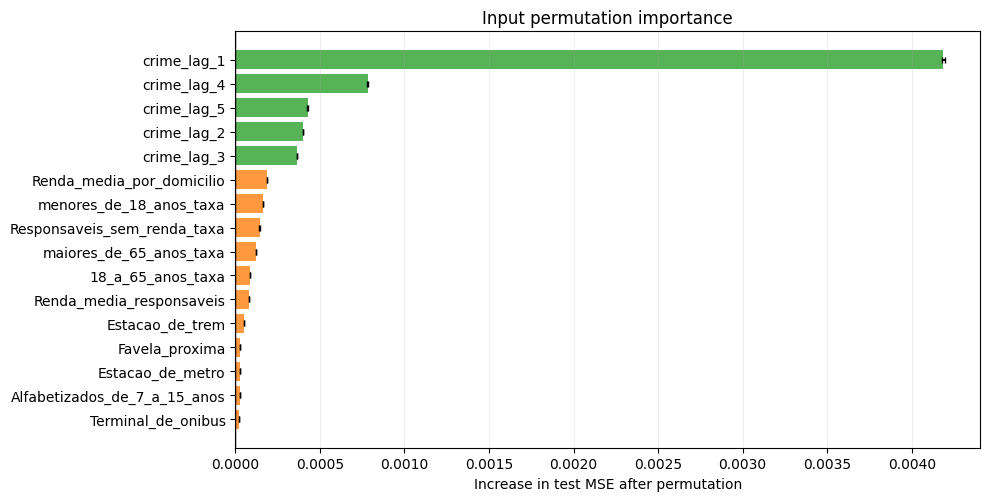

In [123]:
@torch.no_grad()
def permutation_importance_by_input(model, loader, device, static_names=None,
                                    repeats=3, random_seed=42):
    model.eval()
    baseline = evaluate_current_model(model, loader, device)["MSE"]
    sample = next(iter(loader))
    static_dim = sample.x_static.shape[1]
    dynamic_dim = sample.x_dynamic.shape[1]
    if static_names is None or len(static_names) != static_dim:
        static_names = [f"static_{i}" for i in range(static_dim)]
    dynamic_names = [f"crime_lag_{dynamic_dim-i}" for i in range(dynamic_dim)]

    rows = []
    for modality, dim, names in [
        ("static", static_dim, static_names),
        ("dynamic", dynamic_dim, dynamic_names),
    ]:
        for feature_index in range(dim):
            repeated_mse = []
            for repeat in range(repeats):
                pred_all, target_all = [], []
                generator = torch.Generator(device=device)
                generator.manual_seed(random_seed + 1000*feature_index + 17*repeat + (0 if modality=="static" else 100000))
                for data in loader:
                    data = data.to(device)
                    x_static = data.x_static.clone()
                    x_dynamic = data.x_dynamic.clone()
                    n = x_static.shape[0]
                    permutation = torch.randperm(n, generator=generator, device=device)
                    if modality == "static":
                        x_static[:, feature_index] = x_static[permutation, feature_index]
                    else:
                        x_dynamic[:, feature_index] = x_dynamic[permutation, feature_index]
                    prediction, _ = model(x_static, x_dynamic, data.edge_index)
                    target = data.y.float().view_as(prediction)
                    pred_all.append(prediction.cpu())
                    target_all.append(target.cpu())
                prediction = torch.cat(pred_all).numpy()
                target = torch.cat(target_all).numpy()
                repeated_mse.append(float(np.mean((prediction-target)**2)))
            rows.append({
                "modality": modality,
                "feature": names[feature_index],
                "baseline_MSE": baseline,
                "permuted_MSE_mean": np.mean(repeated_mse),
                "permuted_MSE_std": np.std(repeated_mse, ddof=1) if repeats > 1 else 0.0,
                "delta_MSE": np.mean(repeated_mse)-baseline,
            })
    return pd.DataFrame(rows)


static_feature_names = list(static_dt.columns) if len(static_dt.columns) == S else None
permutation_importance = permutation_importance_by_input(
    model, test_loader, device, static_names=static_feature_names,
    repeats=3, random_seed=seed
)
display(permutation_importance.sort_values("delta_MSE", ascending=False).head(15))

plot_df = permutation_importance.sort_values("delta_MSE", ascending=True)
plt.figure(figsize=(10, max(5, 0.32*len(plot_df))))
colors = plot_df["modality"].map({"static": "tab:orange", "dynamic": "tab:green"})
plt.barh(plot_df["feature"], plot_df["delta_MSE"], xerr=plot_df["permuted_MSE_std"],
         color=colors, alpha=0.8, capsize=2)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Increase in test MSE after permutation")
plt.title("Input permutation importance")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_input_permutation_importance.png"), dpi=300, bbox_inches="tight")
plt.show()
permutation_importance.to_csv(os.path.join(output_folder, "professional_input_permutation_importance.csv"), index=False)


### Easy explanation — input permutation importance

**Purpose.** Gate dimensions are abstract. Permutation importance returns to the original
named inputs. One feature is shuffled across nodes while all others stay unchanged; the MSE
increase shows how much the frozen model relied on that feature's correct node assignment.

Crime lag 1 is overwhelmingly most important (MSE increase **0.004188**), so the most recent
crime observation is the main forecasting signal. Lags 2–5 also matter. Important static
features include household income, age-group rates, and responsibility-without-income rate.

**Conclusion.** The task is strongly autoregressive, but socioeconomic variables provide
additional signal. A last-value/persistence baseline is essential. Correlated variables may
share or redistribute permutation importance, so this ranking is not causal.


## K. Cluster bootstrap confidence intervals

Node-time cases are not independent. This bootstrap resamples time windows as
clusters, retaining all nodes within each sampled time. It provides more defensible
uncertainty intervals for global gate summaries than treating every row as independent.


,quantity,estimate,bootstrap_ci95_low,bootstrap_ci95_high,bootstrap_std
0,self_mean,0.48947,0.48944,0.48950,0.00002
1,neighbor_mean,0.48146,0.48143,0.48149,0.00001
2,role_difference,0.00801,0.00796,0.00806,0.00003
3,self_effective_static,0.52762,0.52750,0.52774,0.00006
4,neighbor_effective_static,0.56249,0.56224,0.56276,0.00013


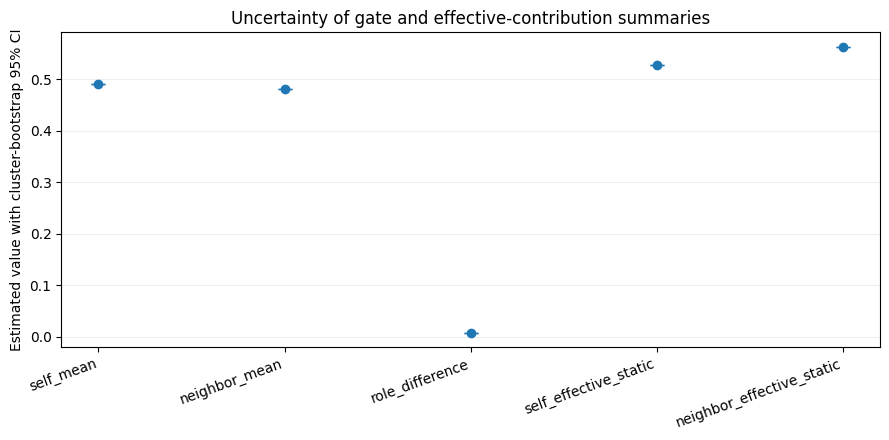

In [124]:
def cluster_bootstrap_gate_summary(frame, cluster_col="time_id", n_bootstrap=1000, random_seed=42):
    rng = np.random.default_rng(random_seed)
    clusters = frame[cluster_col].drop_duplicates().to_numpy()
    estimates = []
    for _ in range(n_bootstrap):
        sampled = rng.choice(clusters, size=len(clusters), replace=True)
        pieces = [frame.loc[frame[cluster_col] == cluster] for cluster in sampled]
        boot = pd.concat(pieces, ignore_index=True)
        estimates.append({
            "self_mean": boot["self_static_gate"].mean(),
            "neighbor_mean": boot["neighbor_static_gate"].mean(),
            "role_difference": (boot["self_static_gate"]-boot["neighbor_static_gate"]).mean(),
            "self_effective_static": boot["self_static_activation_proportion"].mean(),
            "neighbor_effective_static": boot["neighbor_static_activation_proportion"].mean(),
        })
    estimates = pd.DataFrame(estimates)
    records = []
    for column in estimates.columns:
        records.append({
            "quantity": column,
            "estimate": frame["self_static_gate"].mean() if column == "self_mean" else
                        frame["neighbor_static_gate"].mean() if column == "neighbor_mean" else
                        (frame["self_static_gate"]-frame["neighbor_static_gate"]).mean() if column == "role_difference" else
                        frame["self_static_activation_proportion"].mean() if column == "self_effective_static" else
                        frame["neighbor_static_activation_proportion"].mean(),
            "bootstrap_ci95_low": estimates[column].quantile(0.025),
            "bootstrap_ci95_high": estimates[column].quantile(0.975),
            "bootstrap_std": estimates[column].std(ddof=1),
        })
    return pd.DataFrame(records), estimates


bootstrap_summary, bootstrap_samples = cluster_bootstrap_gate_summary(
    explain_frame, cluster_col="time_id", n_bootstrap=1000, random_seed=seed
)
display(bootstrap_summary.round(5))
bootstrap_summary.to_csv(os.path.join(output_folder, "professional_gate_bootstrap_ci.csv"), index=False)

plt.figure(figsize=(9, 4.5))
x = np.arange(len(bootstrap_summary))
lower = bootstrap_summary["estimate"]-bootstrap_summary["bootstrap_ci95_low"]
upper = bootstrap_summary["bootstrap_ci95_high"]-bootstrap_summary["estimate"]
plt.errorbar(x, bootstrap_summary["estimate"], yerr=np.vstack([lower, upper]),
             fmt="o", capsize=5, linewidth=2)
plt.xticks(x, bootstrap_summary["quantity"], rotation=20, ha="right")
plt.ylabel("Estimated value with cluster-bootstrap 95% CI")
plt.title("Uncertainty of gate and effective-contribution summaries")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_gate_bootstrap_ci.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — bootstrap confidence intervals

**Purpose.** Bootstrap intervals show how much summary values change when test time windows
are resampled. Narrow intervals mean the reported average is stable across the available test
periods.

All intervals are extremely narrow. For example, the self mean is approximately
0.48944–0.48950 and the role difference 0.00796–0.00806. Thus these averages are stable over
the resampled test windows.

**Important limitation.** These intervals do not retrain the model. They do not measure
uncertainty from random initialization, optimization, or a different temporal split. Use
5–10 matched training seeds for claims about architectural reliability.


## L. Exportable summary for comparison with GMU and GMU-GNN

To defend the proposed model, train all three models with identical preprocessing,
splits, seeds, hidden dimension, optimizer and training budget. Compare prediction
metrics separately from explainability metrics. The proposed model has two role-specific
gates; GMU and GMU-GNN have one pre-graph gate, so compare common statistics without
claiming that the gate semantics are identical.

Recommended cross-model evidence:

1. test MSE, RMSE and MAE across multiple seeds;
2. global gate mean, variance, entropy and saturation;
3. gate–crime Spearman association;
4. effective activation proportions;
5. fixed-0.5 and shuffled-gate performance degradation;
6. static/dynamic ablation and input permutation importance;
7. only for the proposed model: self–neighbor separation and its intervention benefit.


In [125]:
def build_model_explainability_summary(model_name, metrics, frame, gate_health,
                                       intervention_table, association_table):
    learned = intervention_table.loc[
        intervention_table["intervention"] == "Learned gates"
    ].iloc[0]
    balanced = intervention_table.loc[
        intervention_table["intervention"] == "Balanced gates (0.5, 0.5)"
    ].iloc[0]
    shuffled = intervention_table.loc[
        intervention_table["intervention"] == "Shuffled learned gate logits"
    ].iloc[0]
    self_assoc = association_table.query(
        "role == 'Self' and crime_variable == 'input_crime'"
    ).iloc[0]
    neigh_assoc = association_table.query(
        "role == 'Neighbor' and crime_variable == 'input_crime'"
    ).iloc[0]
    return pd.DataFrame([{
        "model": model_name,
        "test_MSE": metrics["MSE"],
        "test_RMSE": metrics["RMSE"],
        "test_MAE": metrics["MAE"],
        "self_gate_mean": frame["self_static_gate"].mean(),
        "neighbor_gate_mean": frame["neighbor_static_gate"].mean(),
        "self_gate_std_featurewise": gate_health.query("role == 'self'")["global_std"].iloc[0],
        "neighbor_gate_std_featurewise": gate_health.query("role == 'neighbor'")["global_std"].iloc[0],
        "self_gate_entropy": gate_health.query("role == 'self'")["mean_entropy_0_to_1"].iloc[0],
        "neighbor_gate_entropy": gate_health.query("role == 'neighbor'")["mean_entropy_0_to_1"].iloc[0],
        "self_crime_spearman": self_assoc["spearman_rho"],
        "neighbor_crime_spearman": neigh_assoc["spearman_rho"],
        "self_effective_static_proportion": frame["self_static_activation_proportion"].mean(),
        "neighbor_effective_static_proportion": frame["neighbor_static_activation_proportion"].mean(),
        "balanced_gate_delta_MSE": balanced["MSE"]-learned["MSE"],
        "shuffled_gate_delta_MSE": shuffled["MSE"]-learned["MSE"],
        "self_neighbor_mean_difference": (frame["self_static_gate"]-frame["neighbor_static_gate"]).mean(),
    }])


model_explainability_summary = build_model_explainability_summary(
    "M11 adaptive vector-gated GNN", metrics, explain_frame,
    gate_health, gate_interventions, gate_crime_associations
)
display(model_explainability_summary.T)
model_explainability_summary.to_csv(
    os.path.join(output_folder, "professional_model_explainability_summary.csv"), index=False
)


def compare_exported_model_summaries(csv_paths):
    # Load compatible one-row summary CSVs exported by each model notebook.
    tables = [pd.read_csv(path) for path in csv_paths]
    comparison = pd.concat(tables, ignore_index=True)
    display(comparison)
    return comparison


# After exporting equivalent summaries from GMU and GMU-GNN, use:
# comparison = compare_exported_model_summaries([
#     "results/GMU/professional_model_explainability_summary.csv",
#     "results/GMU_GNN/professional_model_explainability_summary.csv",
#     os.path.join(output_folder, "professional_model_explainability_summary.csv"),
# ])


,0
model,M11 adaptive vector-gated GNN
test_MSE,0.000065
test_RMSE,0.008044
test_MAE,0.005234
self_gate_mean,0.489469
neighbor_gate_mean,0.481459
self_gate_std_featurewise,0.285324
neighbor_gate_std_featurewise,0.201731
self_gate_entropy,0.719346
neighbor_gate_entropy,0.872422


## Overall interpretation of the 100-epoch LayerNorm model

### What improved compared with the 50-epoch normalized run?

| Quantity | 50 epochs | 100 epochs | Interpretation |
|---|---:|---:|---|
| Test MSE | 0.000110 | **0.000065** | About 41% lower |
| Test RMSE | 0.010510 | **0.008044** | Better |
| Test MAE | 0.007373 | **0.005234** | Better |
| Test R² | 0.961926 | **0.977696** | Better |
| Self effective static | 0.5179 | 0.5276 | Still balanced |
| Neighbor effective static | 0.5752 | 0.5625 | Still balanced |
| Self gate–crime Spearman | −0.755 | −0.659 | Still strong negative |
| Neighbor gate–crime Spearman | 0.382 | 0.348 | Still moderate positive |
| Self–neighbor mean difference | −0.00046 | **+0.00801** | Small role offset emerges |

### Are the results good?

Yes, this run is substantially stronger than the 50-epoch run. It combines:

1. strong predictive performance (MSE 0.000065 and R² 0.9777);
2. balanced static/dynamic activation scales after LayerNorm;
3. strong feature-wise gate specialization without total collapse;
4. different crime-dependent behavior for self and neighbor pathways;
5. a 50% full-versus-dynamic-only MSE reduction in the post-hoc ablation;
6. severe degradation when learned gates are shuffled;
7. interpretable original-feature importance dominated by recent crime history.

### What should you claim?

> After separately normalizing modality representations and allowing sufficient training,
> the model achieved strong forecasting accuracy while retaining interpretable feature-wise
> gating. Self fusion increasingly favored dynamic history at higher crime intensity, whereas
> neighborhood fusion shifted relatively toward static context. Shuffled-gate and modality
> ablations indicated that the learned fusion assignments were functionally important.

### What should you not claim yet?

- Do not call gate correlations causal effects.
- Do not interpret latent dimensions as named socioeconomic variables.
- Do not use tiny p-values as evidence of large practical effects.
- Do not claim strict unseen-node induction while the inductive wrapper remains commented out.
- Do not declare final superiority from one seed.
- Do not interpret extreme fixed-gate intervention percentages as normal performance gains.

### Final comparison with the old unnormalized run

The 100-epoch normalized model has slightly better MSE and R² than the old unnormalized run,
while the unnormalized run has lower MAE. The normalized model is much more defensible for
gate interpretation because effective branch magnitudes are balanced rather than 94–96%
static-dominated. Therefore, the normalized 100-epoch model is the stronger *research model*
at present, but this conclusion must be confirmed across matched random seeds and with a
proper training-only/chronological checkpoint rule.


## M. How to report the explainability evidence

### Strong claims supported by this notebook

- The model learns separate, input-dependent, feature-wise modality gates for
  self-information and neighbor messages.
- Gate distributions and feature-wise analyses show whether the global mean hides
  specialization.
- Effective activation proportions quantify the magnitude entering fusion rather
  than relying on coefficients alone.
- Intervention results test whether learned gate organization matters for prediction.
- Permutation importance connects latent fusion behavior back to original variables.

### Claims to avoid

- A gate is not a causal effect of a modality.
- A mean gate of 0.5 does not by itself mean equal contribution or model failure.
- Correlation between crime and a gate does not prove that crime causes modality switching.
- One trained seed is insufficient to claim stable explainability.

### Best publication protocol

Run GMU, GMU-GNN and the proposed model using at least five identical random seeds.
Report mean and standard deviation of prediction metrics and common explainability
statistics. Use the proposed model's self–neighbor separation as an additional analysis,
not as a directly equivalent GMU statistic. Treat fixed/shuffled-gate intervention,
ablation and permutation importance as the principal faithfulness evidence; use raw
gate plots as supporting descriptive evidence.
